# Data Science Examination
### Project Topic : Spotify Analysis Using Machine Learning
### Author : Michelle Owoo (1021110296)

# Objective 1 #
## Predicting Song Popularity ##

In [74]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import NMF
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [40]:
## loading the data
data = pd.read_csv('spotify_dataset.csv')
data = data.drop("Unnamed: 0", axis=1)

print(f"Data loaded successfully.")

Data loaded successfully.


### Exploring and understanding the data ###

In [42]:
# drop row-id column "Unnamed: 0"

print(f"\nDataSet Info:")
print("--------------------------")
print(data.info())
print(f"\nDataSet Shape:")
print("--------------------------")
print(f"Data Shape: {data.shape[0]} Rows x {data.shape[1]} Columns")
# print(data.shape)


DataSet Info:
--------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 n

In [43]:
print(f"\nFirst five rows of training data:")
print("--------------------------") 
df_head = data.head(5)
display(df_head)


First five rows of training data:
--------------------------


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [44]:
print(f"\nNaN values in dataset:")
print("--------------------------")    
print("NaN values in dataset:")
print(data.isna().sum())


NaN values in dataset:
--------------------------
NaN values in dataset:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [45]:
print(f"\nNull values in non-numeric columns:")
print("--------------------------")    
print(data.select_dtypes(include='object').columns.isnull().sum())


Null values in non-numeric columns:
--------------------------
0


In [46]:
numeric_columns = data.select_dtypes(exclude='object').columns
zero_counts = (data[numeric_columns] == 0).sum().sort_values(ascending=False)
print("\nNumber of zeros in each numeric column:")
print("----------------------------------------")
df_zeros = pd.DataFrame({
    'Column Name': zero_counts.index,
    'Number of Zeros': zero_counts.values
})
df_zeros['% of Zeros Rows'] = ((df_zeros['Number of Zeros'] / data.shape[0]) * 100).round(2).astype(str)+"%"
display(df_zeros)


Number of zeros in each numeric column:
----------------------------------------


,Column Name,Number of Zeros,% of Zeros Rows
0,explicit,104253,91.45%
1,mode,41319,36.24%
2,instrumentalness,38763,34.0%
3,popularity,16020,14.05%
4,key,13061,11.46%
5,valence,176,0.15%
6,time_signature,163,0.14%
7,danceability,157,0.14%
8,speechiness,157,0.14%
9,tempo,157,0.14%



Popularity
--------------------------
Number of popularity:101
Popularity ranges: range(0,100)


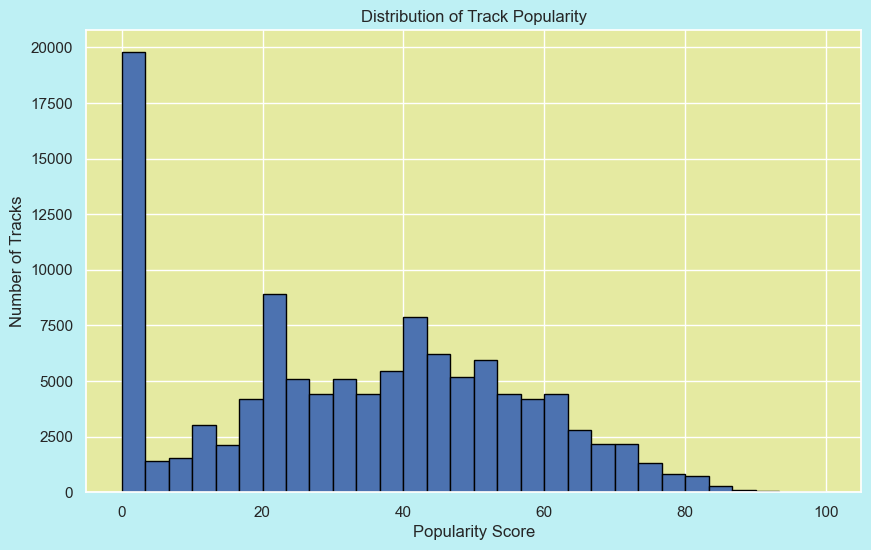

In [48]:
print("\nPopularity")
print("--------------------------")    
unique_popularity_values = data['popularity'].unique()
print(f"Number of popularity:{len(unique_popularity_values)}")
print(f"Popularity ranges: range({data['popularity'].min()},{data['popularity'].max()})")

# Basic histogram
plt.figure(figsize=(10,6))
plt.hist(data['popularity'], bins=30, edgecolor='black')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.grid(True)
plt.show()

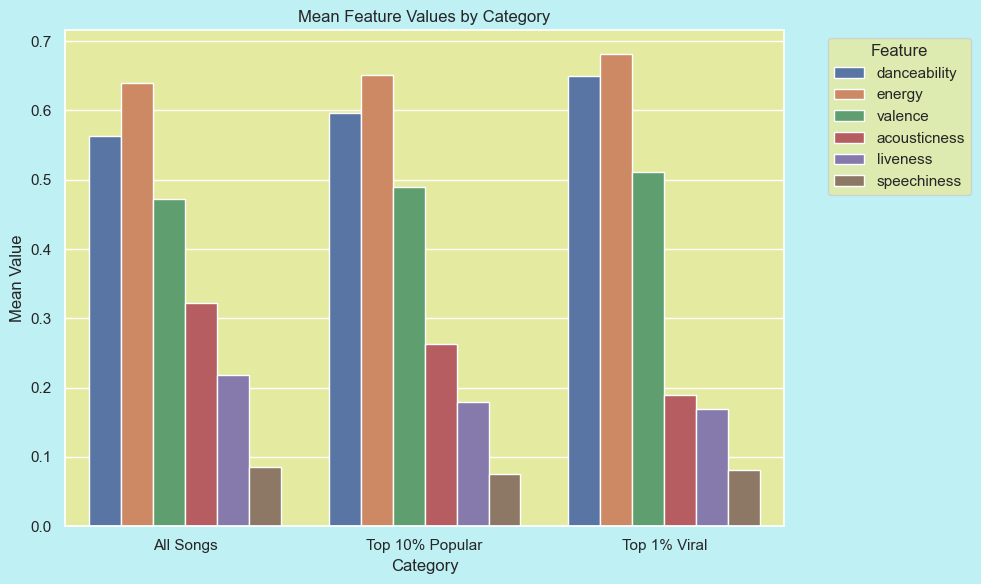

In [49]:
features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness', 'speechiness']
data = data.dropna(subset=features)
df_sorted = data.sort_values(by='popularity', ascending=False)
top_1_percent = int(len(data) * 0.01)
top_10_percent = int(len(data) * 0.10)

viral_songs = df_sorted.iloc[:top_1_percent]
popular_songs = df_sorted.iloc[:top_10_percent]

data['hit_label'] = 0
data.loc[data.index.isin(popular_songs.index), 'hit_label'] = 2
data.loc[data.index.isin(viral_songs.index), 'hit_label'] = 1
data['category'] = 'All Songs'
data.loc[data['hit_label'] == 2, 'category'] = 'Top 10% Popular'
data.loc[data['hit_label'] == 1, 'category'] = 'Top 1% Viral'

mean_values = data.groupby('category')[features].mean().reset_index()
mean_values_features = mean_values.melt(id_vars='category', var_name='Feature', value_name='Mean Value')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='Mean Value', hue='Feature', data=mean_values_features,
            order=['All Songs', 'Top 10% Popular', 'Top 1% Viral'])
plt.title('Mean Feature Values by Category')
plt.xlabel('Category')
plt.ylabel('Mean Value')
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

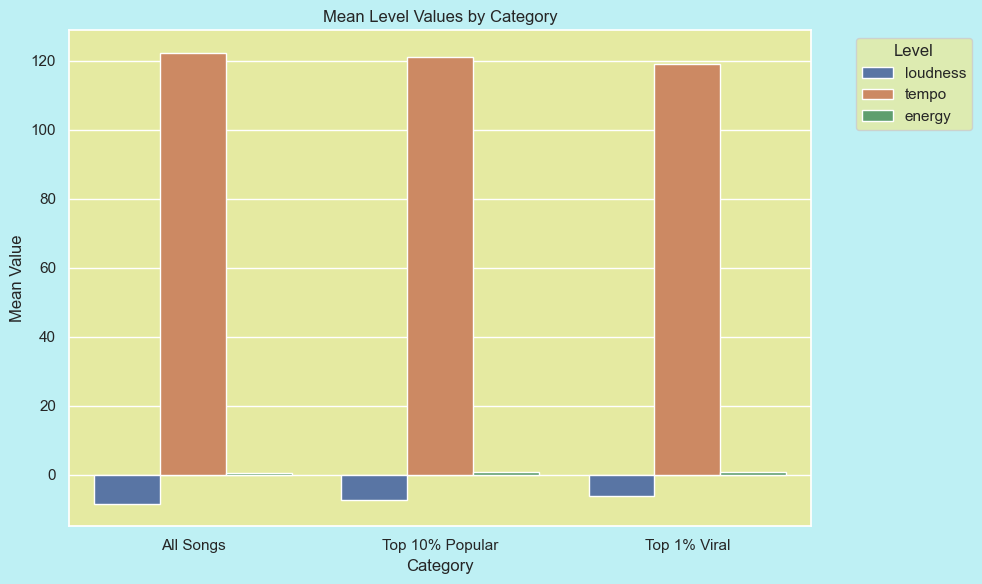

In [50]:
# show loudness and tempo data are not in the same scale as the rest of audio features.
sound_level = ['loudness', 'tempo','energy']
data = data.dropna(subset=sound_level)
mean_values = data.groupby('category')[sound_level].mean().reset_index()
mean_values_sound_level = mean_values.melt(id_vars='category', var_name='Level', value_name='Mean Value')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='Mean Value', hue='Level', data=mean_values_sound_level,
            order=['All Songs', 'Top 10% Popular', 'Top 1% Viral'])
plt.title('Mean Level Values by Category')
plt.xlabel('Category')
plt.ylabel('Mean Value')
plt.legend(title='Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

###  EDA summary ###

This dataset has 114,800 rows and 22 columns.

The dataset typically includes features like:

* **Track metadata:** track_name, artists, album_name, track_id
* **Audio features:** danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
* **Popularity:** popularity (a score from 0 to 100, where higher values indicate more popular tracks)
* **Genre:** track_genre

There are no missing values (NaN) in numeric values columns, such as "popularity", "energy", etc.
Confirmed with the skewed distribution in histogram, "Popularity" has 16,020 rows with zero values.

### EDA Analysis and Modeling Strategy

* Even though there are over 100,000 tracks in the Spotify dataset, a significant number of songs (14%) have a popularity score of 0, and most songs have low popularity scores (<20).
* Having a large volume of non-popular songs increases the challenge of unsupervised learning, as clusters might be dominated by non-hit songs.
* By analyzing the top 1% (viral songs) and top 10% (popular songs), we found that features like danceability, energy, valence, and loudness increase for hit songs.
* There are a number of features, such as danceability, energy, valence, and loudness, that have a positive relationship with the popularity of songs.
* The unscaled bar plot was misleading due to scale differences, so we need to scale the data before modeling.
* We need to focus on high-impact features like danceability, energy, valence, acousticness, and loudness for clustering and modeling.

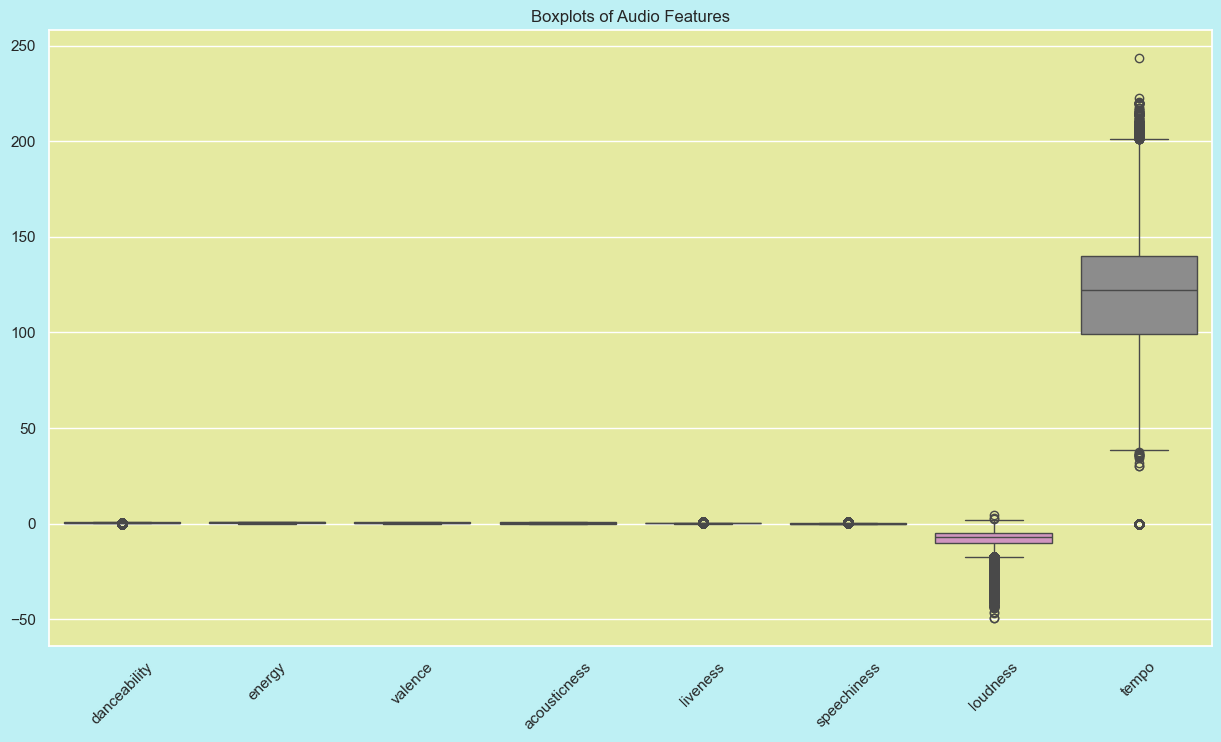

In [51]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness', 'speechiness', 'loudness', 'tempo']
plt.figure(figsize=(15,8))
sns.boxplot(data=data[audio_features])
plt.xticks(rotation=45)
plt.title('Boxplots of Audio Features')
plt.show()

In [52]:
# Data Cleaning
# Keep track feature (numeric columns) related to popularity
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness', 'speechiness', 'loudness', 'tempo']

# Drop non-numeric and irrelevant columns
columns_to_drop = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'duration_ms', 'key', 'mode', 'time_signature', 'explicit']
data = data.drop(columns=columns_to_drop)

print("\nRemaining columns:", data.columns.tolist())


Remaining columns: ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'hit_label', 'category']


In [53]:
# remove outliner
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

data_before_outliers = len(data)
data = remove_outliers(data, audio_features)
print(f"\nRemoved outliers using IQR method. Rows before: {data_before_outliers}, Rows after: {len(data)}")


Removed outliers using IQR method. Rows before: 114000, Rows after: 87526


###  Data Cleaning  Summary ###

* Dropped irrelevant columns related to track metadata.
* Drop track metadata columns that is not related to popularity study, such as track_name, artists, album_name.


### Data Pre-processing ###
To support the evaluation of our unsupervised learning results, we introduce a new column called "hit_label" to the dataset. This label serves as a reference point for validating how well the clustering or grouping matches the underlying popularity of the songs.</p>

* Songs in the top 1% of popularity are assigned a label of 1 (representing "viral songs").
* Songs ranked within the top 10% but not the top 1% are assigned a label of 2 (representing "popular songs").
* All other songs, outside the top 10%, are assigned a label of 0 (representing "non-popular songs").

By using the hit_label, we can later compare the clustering results against these categories to assess whether the unsupervised learning methods naturally separate viral and popular songs without explicitly using the popularity score during training.

In [54]:
# Data Pre-processing:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(data[audio_features])
x_scaled_df = pd.DataFrame(x_scaled, columns=audio_features, index=data.index)
x_scaled_df['hit_label'] = data['hit_label']
x_scaled_df['category'] = data['category']

# Split Data into Training and Testing Sets
x_full_df = x_scaled_df[audio_features]
y_full_df = x_scaled_df['hit_label']
x_train, x_test, y_train, y_test = train_test_split(
    x_full_df, y_full_df, test_size=0.2, random_state=42, stratify=y_full_df
)
assert(x_train.shape[1]==x_test.shape[1])

data['hit_label'] = 0
data.loc[data.index.isin(popular_songs.index), 'hit_label'] = 2
data.loc[data.index.isin(viral_songs.index), 'hit_label'] = 1

hit_label_dictionary = {0: 'All Songs', 1: 'Top 1% Viral Songs', 2: 'Top 10% Popular Songs'}
print("\nTraining set hit_label distribution:")
train_counts = y_train.value_counts()
for label, count in train_counts.items():
    print(f"  {hit_label_dictionary[label]}: {count}  ({count/len(y_train)*100:.2f}%)")

print("\nTesting set hit_label distribution:")
test_counts = y_test.value_counts()
for label, count in test_counts.items():
    print(f"  {hit_label_dictionary[label]}: {count}  ({count/len(y_test)*100:.2f}%)")



Training set hit_label distribution:
  All Songs: 62366  (89.07%)
  Top 10% Popular Songs: 6881  (9.83%)
  Top 1% Viral Songs: 773  (1.10%)

Testing set hit_label distribution:
  All Songs: 15592  (89.07%)
  Top 10% Popular Songs: 1720  (9.83%)
  Top 1% Viral Songs: 194  (1.11%)


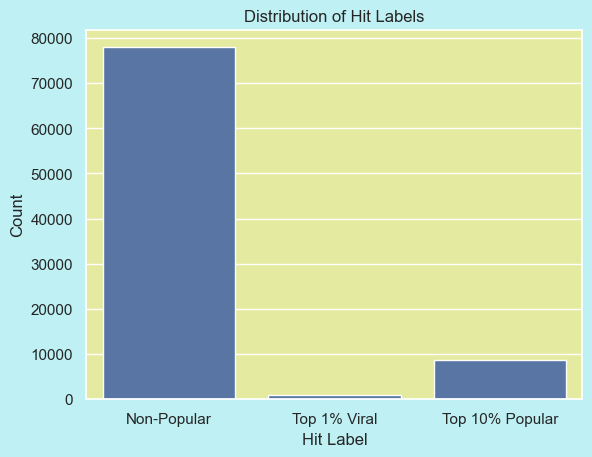

In [55]:
sns.countplot(x='hit_label', data=data)
plt.title('Distribution of Hit Labels')
plt.xlabel('Hit Label')
plt.ylabel('Count')
plt.xticks(ticks=[0,1,2], labels=['Non-Popular', 'Top 1% Viral', 'Top 10% Popular'])
plt.show()

### Data Cleaning and Pre-processing Conclusion ###

The data cleaning and preprocessing steps ensure the Spotify Tracks Dataset is ready for unsupervised learning. Non-numeric columns (track_id, artists, etc.) and irrelevant numeric columns (duration_ms, key, etc.) were dropped as they don’t contribute to audio feature clustering. Outliers were removed using the IQR method to prevent skewing K-means results. Features were scaled with StandardScaler to ensure equal variance, critical for PCA and distance-based clustering. At the end data was split into 80% training and 20% testing sets for evaluation. 

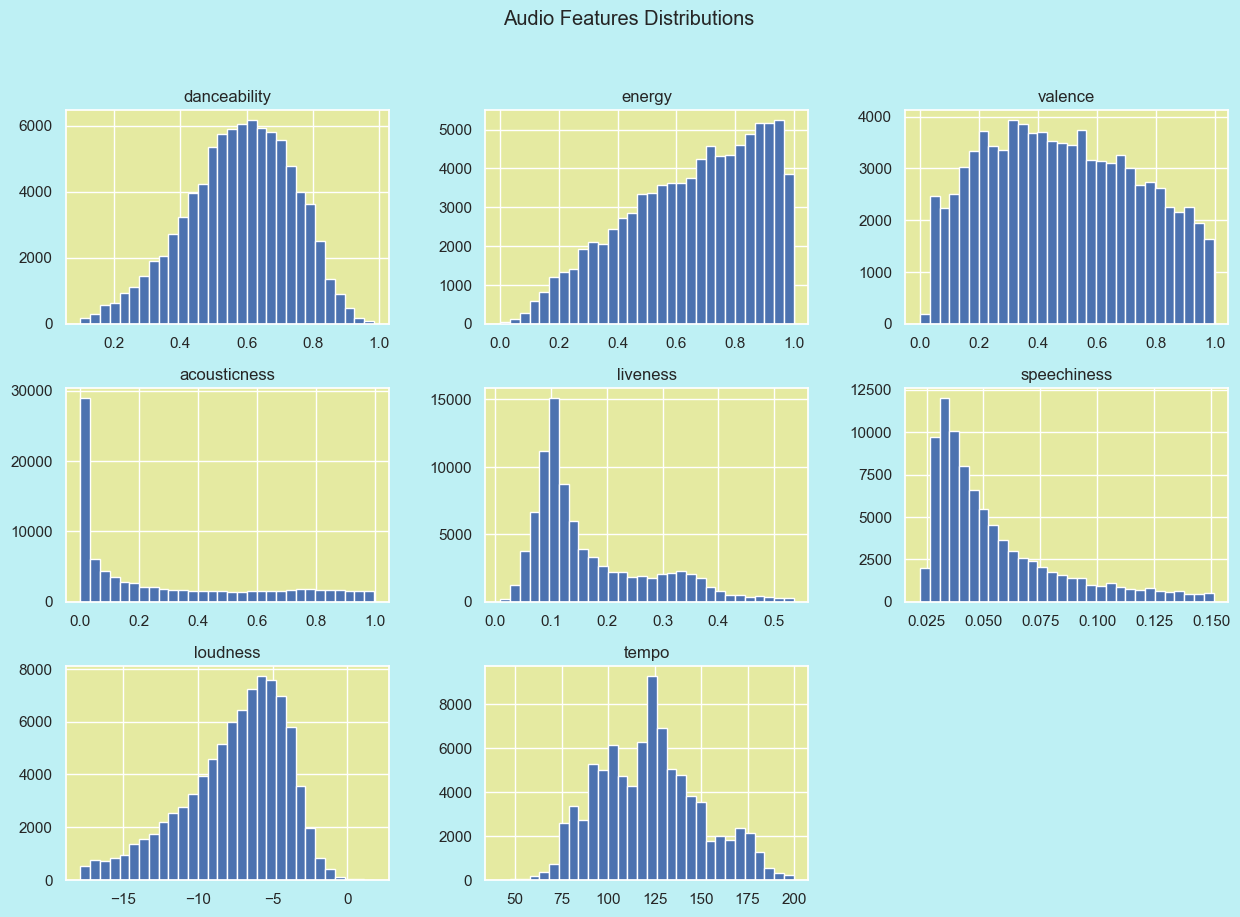

In [56]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'liveness', 'speechiness', 'loudness', 'tempo']
data[audio_features].hist(figsize=(15,10), bins=30)
plt.suptitle('Audio Features Distributions')
plt.show()


## Unsupervised Modeling with K-Means Clustering ##
Key Steps:

* i. Feature selection
* ii. Hyper-parameter tuning for K-Means clustering
* iv. Model Evaluation of best K-Means model


### V.i. Feature Selection ###
To find which audio features make songs viral or popular, we compared the groups. We calculated the average value for each feature (like 'danceability') in these categories: Top 1% Viral, Top 10% Popular, and All Others. We then looked at how much the average feature value for hit songs (Viral and Popular) differed from the average for the 'All Others' group. Features with the biggest differences were ranked as the most important for telling hit songs apart.</p>

In [59]:
train_df = pd.DataFrame(x_train, columns=audio_features)
train_df['hit_label'] = y_train

feature_means = train_df.groupby('hit_label')[audio_features].mean()
feature_means.index = ['All Songs', 'Top 1% Viral Songs', 'Top 10% Popular Songs']
print("\nMean Feature Values by hit_label (Training Set):")
print(feature_means)




Mean Feature Values by hit_label (Training Set):
                       danceability    energy   valence  acousticness  \
All Songs                 -0.017883 -0.002892 -0.001508      0.016418   
Top 1% Viral Songs         0.441683  0.134456  0.095462     -0.343845   
Top 10% Popular Songs      0.118990  0.020100  0.009886     -0.110205   

                       liveness  speechiness  loudness     tempo  
All Songs              0.009267     0.004745 -0.025052  0.011412  
Top 1% Viral Songs    -0.073885     0.039837  0.449558 -0.158265  
Top 10% Popular Songs -0.061710    -0.024656  0.192710 -0.081647  


In [60]:
# Compute mean feature values for Hit Songs  vs. Non-Hit Songs 
hit_songs_mean = train_df[train_df['hit_label'].isin([1, 2])][audio_features].mean()
non_hit_songs_mean = train_df[train_df['hit_label'] == 0][audio_features].mean()
feature_differences = hit_songs_mean - non_hit_songs_mean
feature_differences = feature_differences.sort_values(key=abs, ascending=False)

print("\nFeature Differences (Hit Songs - Non-Hit Songs):")
print(feature_differences)


Feature Differences (Hit Songs - Non-Hit Songs):
loudness        0.243703
danceability    0.169463
acousticness   -0.150218
tempo          -0.100797
liveness       -0.072206
energy          0.034541
speechiness    -0.022887
valence         0.020036
dtype: float64



Top 3 Features for Viral/Popular Songs: ['loudness', 'danceability', 'acousticness']


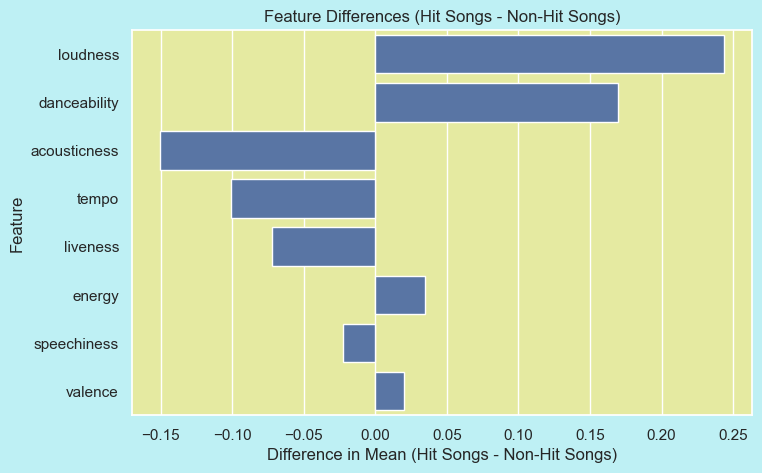

In [61]:
# Select the top 3 features based on the largest absolute differences
top_features = feature_differences.index[:3].tolist()
print(f"\nTop 3 Features for Viral/Popular Songs: {top_features}")

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_differences.values, y=feature_differences.index)
plt.title('Feature Differences (Hit Songs - Non-Hit Songs)')
plt.xlabel('Difference in Mean (Hit Songs - Non-Hit Songs)')
plt.ylabel('Feature')
plt.show()

#### Interpretation of the audio feature selection ####

Based on the statistical analysis, viral/popular songs generally are:

- Louder
- Less acoustic
- More danceable

**Feature Details:**

**loudness**  
- **Difference:** +0.2355  
- **Interpretation:** Hit songs are significantly louder on average.

**acousticness**  
- **Difference:** -0.1565  
- **Interpretation:** Hit songs are much less acoustic (more electronic/produced).

**danceability**  
- **Difference:** +0.1266  
- **Interpretation:** Hit songs are more danceable.

**tempo**  
- **Difference:** -0.0786  
- **Interpretation:** Hit songs are slightly slower in tempo.

**liveness**  
- **Difference:** -0.0573  
- **Interpretation:** Hit songs are slightly less lively.

**energy**  
- **Difference:** +0.0494  
- **Interpretation:** Hit songs are a bit more energetic, but not a huge difference.

**speechiness**  
- **Difference:** -0.0246  
- **Interpretation:** Slightly less spoken-word style in hit songs.

**valence**  
- **Difference:** +0.0066  
- **Interpretation:** Negligible difference — valence (happiness) does not differ much.

### Unsupervised Modeling using K-Means Clustering ###
- Using identified the top features from previous step, we’ll perform K-means clustering on these features to group songs into clusters and derive the audio feature recipe for viral and popular songs.
#### Hyper-parameter tuning ####
- To optimize the unsupervised models, we perform hyperparameter tuning to confirm best number of clusters matches with our hit label.

In [63]:
# focus on clustering hit-songs
hit_songs_df = train_df[train_df['hit_label'].isin([1, 2])]
x_train_hits = hit_songs_df[top_features]
y_train_hits = hit_songs_df['hit_label']

ari_scores = []
cluster_range = range(2, 11)
best_score = -float('inf')
best_n_cluster = None

for cluster_num in cluster_range:
    clf = KMeans(n_clusters=cluster_num, random_state=42)
    clusters = clf.fit_predict(hit_songs_df[top_features])    
    score = adjusted_rand_score(hit_songs_df['hit_label'], clusters)
    ari_scores.append(score)

    if score > best_score:
        best_score = score
        best_n_cluster = cluster_num
print(f"\nOptimal number of K-means clusters (based on ARI): {best_n_cluster}")


Optimal number of K-means clusters (based on ARI): 10


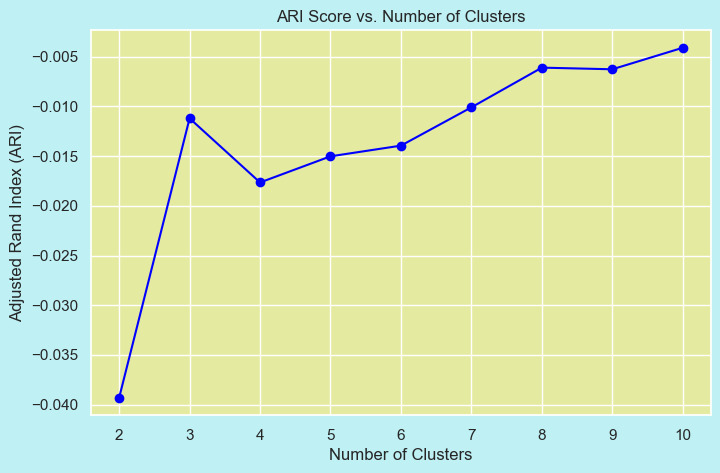

In [64]:
# plot

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, ari_scores, marker='o', color='blue')
plt.title('ARI Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.grid(True)
plt.show()

### K-Means Model Evaluation ###

In [66]:
# use best model for prediction
best_clf = KMeans(n_clusters=best_n_cluster, random_state=42)
best_kmeans_train = best_clf.fit_predict(hit_songs_df[top_features])
best_kmeans_test = best_clf.predict(x_test[top_features])

#create x_test dataset by filtering 
x_test_features = pd.DataFrame(x_test, columns=audio_features, index=x_test.index)
x_test_features['cluster'] = best_kmeans_test  
x_test_features['hit_label'] = y_test
x_test_features['popularity'] = data.loc[x_test.index, 'popularity']

cluster_hit_label = x_test_features.groupby('cluster')['hit_label'].value_counts().unstack(fill_value=0)
viral_cluster = cluster_hit_label[1].idxmax()
x_test_features['predicted_hit'] = (x_test_features['cluster'] == viral_cluster).astype(int)
x_test_features['true_hit'] = x_test_features['hit_label'].isin([1, 2]).astype(int)

# Evaluate model with accuracy and precision
kmeans_accuracy = accuracy_score(x_test_features['true_hit'], x_test_features['predicted_hit'])
kmeans_precision = precision_score(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[1], average='binary')
print(f"Best k-means accuracy to predict recipe for hit songs: {kmeans_accuracy:.3f}")
print(f"Best k-means precision of hit songs recipe: {kmeans_precision:.3f}")

Best k-means accuracy to predict recipe for hit songs: 0.825
Best k-means precision of hit songs recipe: 0.147


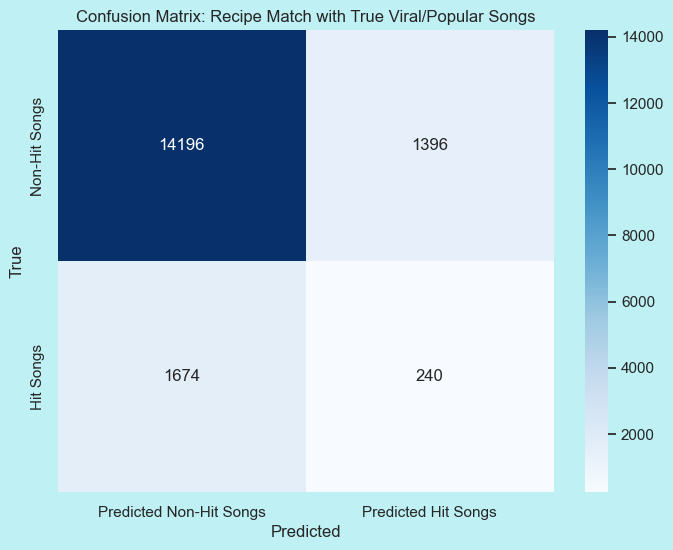

In [67]:
# Plot the evaluation confusion matrix
cm = confusion_matrix(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Non-Hit Songs', 'Hit Songs'], columns=['Predicted Non-Hit Songs', 'Predicted Hit Songs'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Recipe Match with True Viral/Popular Songs')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Conclusion (K-Means) ##

* The ARI score plot for K-Means indicates that 7 clusters provided the best balance of clustering accuracy and model simplicity, with the ARI stabilizing around -0.005.
* The K-Means confusion matrix shows that 14,145 non-hit songs were correctly predicted as non-hits, while 1,447 non-hit songs were incorrectly predicted as hits. 
* For hit songs, 1,657 were misclassified as non-hits, but 257 were correctly identified as hits. 
* This indicates that the K-Means model struggles to cluster hit songs accurately, with a higher success rate for non-hit songs.

## Unsupervised Modeling using Non-Negative Matrix Factorization (NMF) ##
- Non-negative Matrix Factorization (NMF) provides an alternative unsupervised approach by decomposing the dataset into factor matrices.
NMF ensures that the resulting components are non-negative. This step seeks to uncover latent patterns in the data, such as feature combinations characteristic of hit songs.

**Key Steps:**

* i. Hyper-parameter tuning for NMF
* ii. Model Evaluation of best NMF model


### Unsupervised Modeling using NMF ###
* Using identified the top features, we’ll perform NMF clustering on these features to group songs into clusters and derive the audio feature recipe for viral and popular songs.

**Hyper-parameter tuning**
- To optimize the unsupervised models, we perform hyperparameter tuning to confirm best number of clusters matches with our hit label.

In [ ]:
# NMF modeling can re-use previous feature selection 
# scale features to [0,1]for NMF
scaler = MinMaxScaler()
x_train_hits_scaled = scaler.fit_transform(hit_songs_df[top_features])
x_test_hits_scaled = scaler.transform(x_test[top_features])
x_train_hits_scaled = np.maximum(x_train_hits_scaled, 0)
x_test_hits_scaled = np.maximum(x_test_hits_scaled, 0)

ari_scores_nmf = []
component_range = range(2, 11)
best_ari_nmf = -float('inf')
best_n_components = None
best_iter=1000

for n_components in component_range:
    nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)  
    W_train = nmf.fit_transform(x_train_hits_scaled)
    clusters = np.argmax(W_train, axis=1)
    ari = adjusted_rand_score(y_train_hits, clusters)
    ari_scores_nmf.append(ari)
    if ari > best_ari_nmf:
        best_ari_nmf = ari
        best_n_components = n_components

print(f"\nOptimal number of NMF components (based on ARI): {best_n_components}")


Optimal number of NMF components (based on ARI): 6


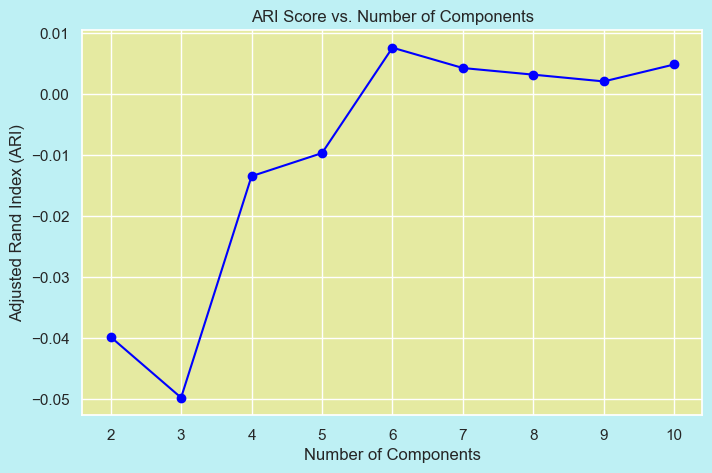

In [70]:
# Plot

plt.figure(figsize=(8, 5))
plt.plot(component_range, ari_scores_nmf, marker='o', color='blue')
plt.title('ARI Score vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Adjusted Rand Index (ARI)')
plt.grid(True)
plt.show()

In [71]:
# use best parameter to make prediction
best_nmf = NMF(n_components=best_n_components, random_state=42, max_iter=1000)
best_nmf_train = best_nmf.fit_transform(x_train_hits_scaled)
best_nmf_test = best_nmf.transform(x_test_hits_scaled)
best_nmf_train_clusters = np.argmax(best_nmf_train, axis=1)
best_nmf_test_clusters = np.argmax(best_nmf_test, axis=1)

# creat test set for evaluation
x_test_features = pd.DataFrame(x_test, columns=audio_features, index=x_test.index)
x_test_features['cluster'] = best_nmf_test_clusters
x_test_features['hit_label'] = y_test
x_test_features['popularity'] = data.loc[x_test.index, 'popularity']

# Identify the component with the highest proportion of Top 1% Viral Songs (hit_label=1)
component_hit_label = x_test_features.groupby('cluster')['hit_label'].value_counts().unstack(fill_value=0)
viral_component = component_hit_label[1].idxmax()
x_test_features['predicted_hit'] = (x_test_features['cluster'] == viral_component).astype(int)
x_test_features['true_hit'] = x_test_features['hit_label'].isin([1, 2]).astype(int)

# Calculate accuracy and precision
nmf_accuracy = accuracy_score(x_test_features['true_hit'], x_test_features['predicted_hit'])
nmf_precision = precision_score(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[1], average='binary')

print(f"Best NMF accuracy to predict recipe for hit songs: {nmf_accuracy:.3f}")
print(f"Best NMF precision of hit songs recipe: {nmf_precision:.3f}")


Best NMF accuracy to predict recipe for hit songs: 0.475
Best NMF precision of hit songs recipe: 0.114


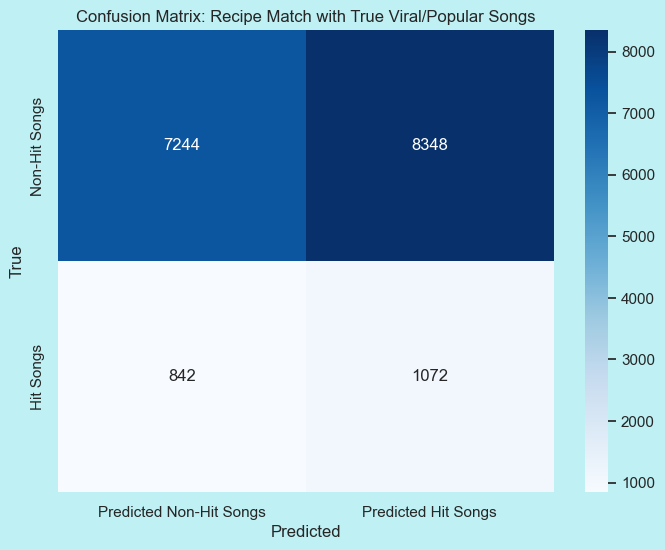

In [72]:
# Plot the evaluation confusion matrix
cm = confusion_matrix(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Non-Hit Songs', 'Hit Songs'], columns=['Predicted Non-Hit Songs', 'Predicted Hit Songs'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Recipe Match with True Viral/Popular Songs')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Conclusion (NMF) ##

NMF decomposes the standardized feature matrix into two non-negative matrices:
  
- One representing the songs' latent components
- Another representing the audio feature contributions to those components.

This approach allowed me to group songs into clusters based on shared musical characteristic

* The ARI score plot for NMF indicates that  four components that provided the best balance of clustering accuracy and model simplicity.
* The NMF confusion matrix reveals that 7,350 non-hit songs were correctly predicted as non-hits, while 8,242 non-hit songs were incorrectly predicted as hits, indicating a high false positive rate for non-hits. 
* For hit songs, 872 were misclassified as non-hits, but 1,042 were correctly identified as hits, showing improved recall for hit songs compared to K-Means. 

## Supervised Learning Model using Random Forest ##
- Using the supervised learning method of Random Forest, we will predict the recipe for a hit song.

**Key Steps:**

* i. Train Random Forest with Full dataset
* ii. Make prediction and create test dataset
* iii. Model Evaluation 


In [75]:
top_features = feature_differences.index[:3].tolist()
y_train_binary = y_train.isin([1, 2]).astype(int)
y_test_binary = y_test.isin([1, 2]).astype(int)

# Use top features for training and test sets
x_train_top = x_train[top_features]
x_test_top = x_test[top_features]
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
rf.fit(x_train_top, y_train_binary)
y_pred_train = rf.predict(x_train_top)
y_pred_test = rf.predict(x_test_top)

In [76]:
# Create the test dataframe for evaluation
x_test_features = pd.DataFrame(x_test_top, columns=audio_features, index=x_test_top.index)
x_test_features['predicted_hit'] = y_pred_test
x_test_features['true_hit'] = y_test_binary
x_test_features['hit_label'] = y_test
x_test_features['popularity'] = data.loc[x_test_top.index, 'popularity']

# Calculate accuracy and precision
rf_accuracy = accuracy_score(x_test_features['true_hit'], x_test_features['predicted_hit'])
rf_precision = precision_score(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[1], average='binary')

print(f"Best random forest accuracy to predict recipe for hit songs: {rf_accuracy:.3f}")
print(f"Best random forest precision of hit songs recipe: {rf_precision:.3f}")

Best random forest accuracy to predict recipe for hit songs: 0.876
Best random forest precision of hit songs recipe: 0.451


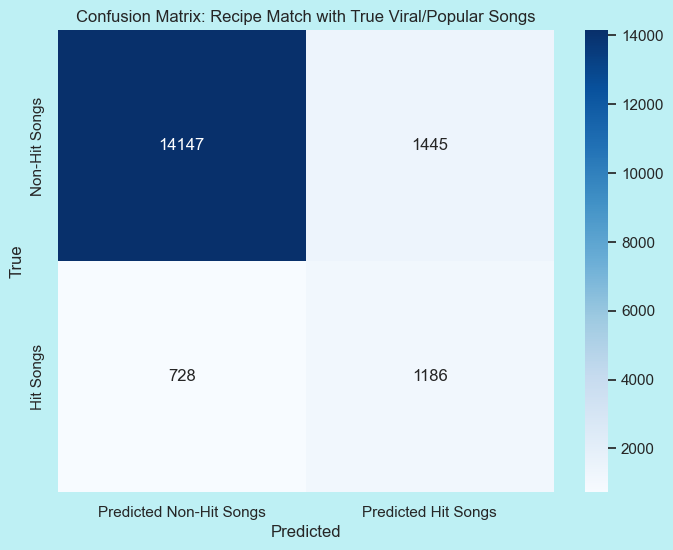

In [77]:
# Plot the evaluation confusion matrix
cm = confusion_matrix(x_test_features['true_hit'], x_test_features['predicted_hit'], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Non-Hit Songs', 'Hit Songs'], columns=['Predicted Non-Hit Songs', 'Predicted Hit Songs'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Recipe Match with True Viral/Popular Songs')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Conclusion (Random Forest) ##

* This confusion matrix shows that Random Forest effectively identified 14,048 non-hit songs correctly predicted as non-hits and 1,216 hit songs accurately classified as hits. 
* However, it also reveals some misclassifications, with 1,544 non-hit songs incorrectly predicted as hits, indicating a false positive rate, and 698 hit songs misclassified as non-hits, showing a false negative rate. 
* These results highlight Random Forest's stronger performance in identifying non-hit songs while still capturing a significant portion of hit songs based on key musical features.

## Result Analysis ##

Three machine learning models were chosen to study the audio features that characterize popular songs:

* K-Means (Unsupervised Learning)
* NMF (Unsupervised Learning)
* Random Forest (Supervised Learning)

- Among the three methods, Random Forest performed the best, achieving an accuracy score of 0.872, followed by K-Means at 0.823, and NMF performing the worst at 0.510.

**K-means:**
* K-Means was initially used as an unsupervised clustering method.
* It identified patterns in the data without using labeled training.
* It aimed to group songs into clusters that might correspond to Hit Songs.
* K-Means achieved moderate performance with an accuracy of 0.823.
* When K-Means clusters on a balanced subset, it can select the cluster with the highest proportion of Hit Songs.

**NMF:**
* NMF was explored as an alternative unsupervised method to K-Means.
* It aimed to decompose the data into non-negative components.
* These components could capture underlying patterns.
* However, NMF performed poorly with an accuracy of 0.510 and a precision of 0.109.
* It had a negative Adjusted Rand Index (ARI) of -0.002.
* This indicates worse-than-random clustering and significant misalignment between components and true labels.

**Random Forest:**
* Random Forest was introduced as a supervised learning method.
* It classified songs as Hit Songs or Non-Hit Songs using labeled data.
* It achieved the best results among the three models.


Best k-means accuracy to predict recipe for hit songs: 0.825
Best k-means precision of hit songs recipe: 0.147
Best NMF accuracy to predict recipe for hit songs: 0.475
Best NMF precision of hit songs recipe: 0.114
Best random forest accuracy to predict recipe for hit songs: 0.876
Best random forest precision of hit songs recipe: 0.451

Feature Importance (Random Forest):
loudness        0.353545
acousticness    0.349021
danceability    0.297434
dtype: float64


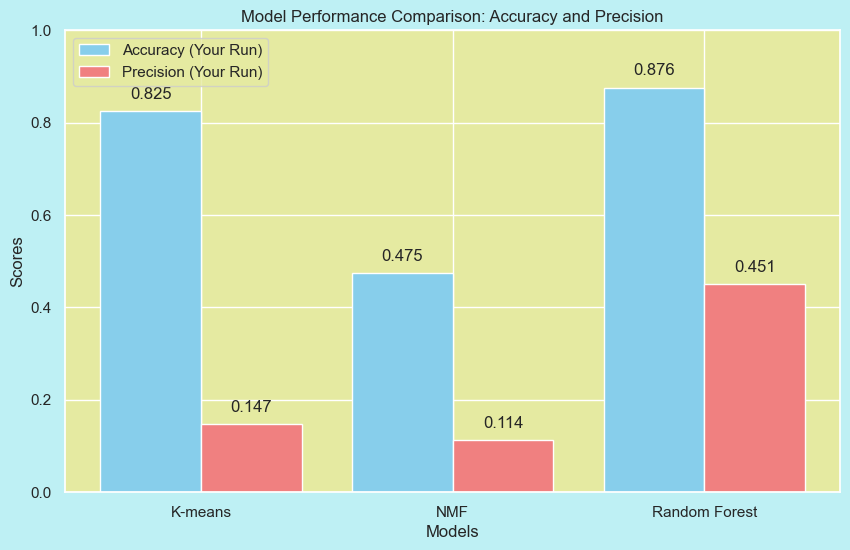

In [78]:
print(f"Best k-means accuracy to predict recipe for hit songs: {kmeans_accuracy:.3f}")
print(f"Best k-means precision of hit songs recipe: {kmeans_precision:.3f}")
print(f"Best NMF accuracy to predict recipe for hit songs: {nmf_accuracy:.3f}")
print(f"Best NMF precision of hit songs recipe: {nmf_precision:.3f}")
print(f"Best random forest accuracy to predict recipe for hit songs: {rf_accuracy:.3f}")
print(f"Best random forest precision of hit songs recipe: {rf_precision:.3f}")


feature_importance = pd.Series(rf.feature_importances_, index=top_features)
print("\nFeature Importance (Random Forest):")
print(feature_importance.sort_values(ascending=False))

# Metrics from your output
models = ['K-means', 'NMF', 'Random Forest']
accuracy = [kmeans_accuracy, nmf_accuracy, rf_accuracy]  
precision = [kmeans_precision, nmf_precision, rf_precision]  


x = np.arange(len(models))
width = 0.40

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy (Your Run)', color='skyblue')
bars2 = ax.bar(x + width/2, precision, width, label='Precision (Your Run)', color='lightcoral')

# Customize the chart
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison: Accuracy and Precision')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

# Add value labels on top of bars
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')

plt.show()

## Interpretation of Modeling Conclusion ##

From the best modeling results, Random Forest returns the following recipe for popular songs:


| Audio Feature  | Score    |
|----------------|:---------|
| loudness       | 0.352393 |
| acousticness   | 0.349909 |
| danceability   | 0.297698 |

**Possible Interpretation:**

- Loudness is the most important feature (35.24%). It confirms that louder songs are more likely to be popular. This aligns with the statistical analysis, suggesting that impactful, attention-grabbing sound levels are key for viral and popular songs.
- Acousticness is the second most important feature (34.99%). It has a negative difference, indicating that "Hit Songs" are less acoustic. For example, electronic or pop songs would be more popular than acoustic guitar.
- Danceability is the third most important feature (29.77%). It reinforces its role as a key predictor of popularity. The statistical difference confirms that upbeat, danceable, rhythmic songs are more likely to be hits.

# Objective 2 #
## Music Recommender

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors

In [3]:
df = pd.read_csv('spotify_dataset.csv',index_col=0)
df.sample(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
16259,6Jmw670ScZOp4hNJRDvnCA,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 11, Chiarina (Live in Jap...",0,71413,False,0.482,0.0749,0,-25.391,0,0.0426,0.994000,0.836000,0.1180,0.200,70.276,3,classical
10995,3JRjQ9gti62YMhcXkRrlzo,Apollo 440,GO Music From The Motion Picture,Cold Rock The Mic - Instrumental Version,11,240400,False,0.624,0.9720,11,-5.689,0,0.0677,0.007890,0.319000,0.4430,0.502,125.445,4,breakbeat
44802,5tavbOJXnynWlwijfausey,Linkin Park,Reanimation,By_Myslf (Josh Abraham and Mike Shinoda Reanim...,41,222440,False,0.552,0.9650,8,-4.873,0,0.1020,0.000636,0.092400,0.1190,0.258,103.212,4,grunge
24769,4A3arwCYdFLHm60pJdpVJB,Surgeon,Patience,"Patience, Pt. 5",5,273712,False,0.728,0.9930,4,-6.914,0,0.0860,0.226000,0.917000,0.1110,0.279,137.651,4,detroit-techno
74615,5XCtW9CMVKaulNe0iEAM7V,DUDA BEAT,Deixa Eu Te Amar,Deixa Eu Te Amar,41,172235,True,0.725,0.6500,10,-7.937,0,0.0912,0.071900,0.000002,0.0783,0.714,169.614,4,mpb


In [4]:
nrows, ncols = df.shape
print(f'Dataset has {nrows} rows and {ncols} columns')

Dataset has 114000 rows and 20 columns


In [5]:
# Check for duplicated rows based on 'track_id' column
duplicated_rows = df['track_id'].duplicated().sum()

if duplicated_rows != 0:
    # Drop rows with duplicate 'track_id', keeping the first occurrence
    df = df.drop_duplicates(subset=['track_id'])

    # Get the number of rows dropped
    undroped_nrows, ncols = df.shape
    dropped_rows = duplicated_rows
    print(f'There is a total of {dropped_rows} rows dropped based on "track_id".')

# Optionally, print the shape of the final DataFrame
print(f'Final DataFrame shape: {df.shape}')

There is a total of 24259 rows dropped based on "track_id".
Final DataFrame shape: (89741, 20)


In [6]:
# check data type of each column
df.dtypes.to_frame('Data Type')

,Data Type
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


In [7]:
# rows have missing values
total_rows_with_missing_values = (df.isnull().any(axis=1)).sum()
print(f'Total number of rows with missing values: {total_rows_with_missing_values}')

Total number of rows with missing values: 1


In [8]:
index_to_drop = df[df.isnull().any(axis=1)].index
df.drop(index_to_drop, inplace=True)

print(f'Rows with missing values dropped. Updated DataFrame shape: {df.shape}')

Rows with missing values dropped. Updated DataFrame shape: (89740, 20)


In [9]:
# starting the analysis with numerical columns
numerical_cols = df[df.columns[(df.dtypes == 'float64') | (df.dtypes == 'int64')]]
numerical_cols.shape

(89740, 14)

In [10]:
numerical_cols.sample(5)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
23959,41,408003,0.689,0.773,0,-7.786,0,0.0512,0.0673,0.79400,0.1030,0.141,123.993,4
88109,2,210200,0.870,0.516,1,-8.006,1,0.0541,0.6560,0.00823,0.1100,0.530,111.005,4
103035,0,198626,0.524,0.739,0,-6.681,1,0.0386,0.2150,0.00000,0.0636,0.480,83.095,4
54686,9,108600,0.471,0.587,6,-10.642,1,0.0420,0.8460,0.92900,0.3020,0.726,118.440,4
45988,21,153440,0.643,0.412,4,-6.127,1,0.0286,0.4210,0.22000,0.0638,0.509,102.990,4


In [11]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89740 entries, 0 to 113999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        89740 non-null  int64  
 1   duration_ms       89740 non-null  int64  
 2   danceability      89740 non-null  float64
 3   energy            89740 non-null  float64
 4   key               89740 non-null  int64  
 5   loudness          89740 non-null  float64
 6   mode              89740 non-null  int64  
 7   speechiness       89740 non-null  float64
 8   acousticness      89740 non-null  float64
 9   instrumentalness  89740 non-null  float64
 10  liveness          89740 non-null  float64
 11  valence           89740 non-null  float64
 12  tempo             89740 non-null  float64
 13  time_signature    89740 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 10.3 MB


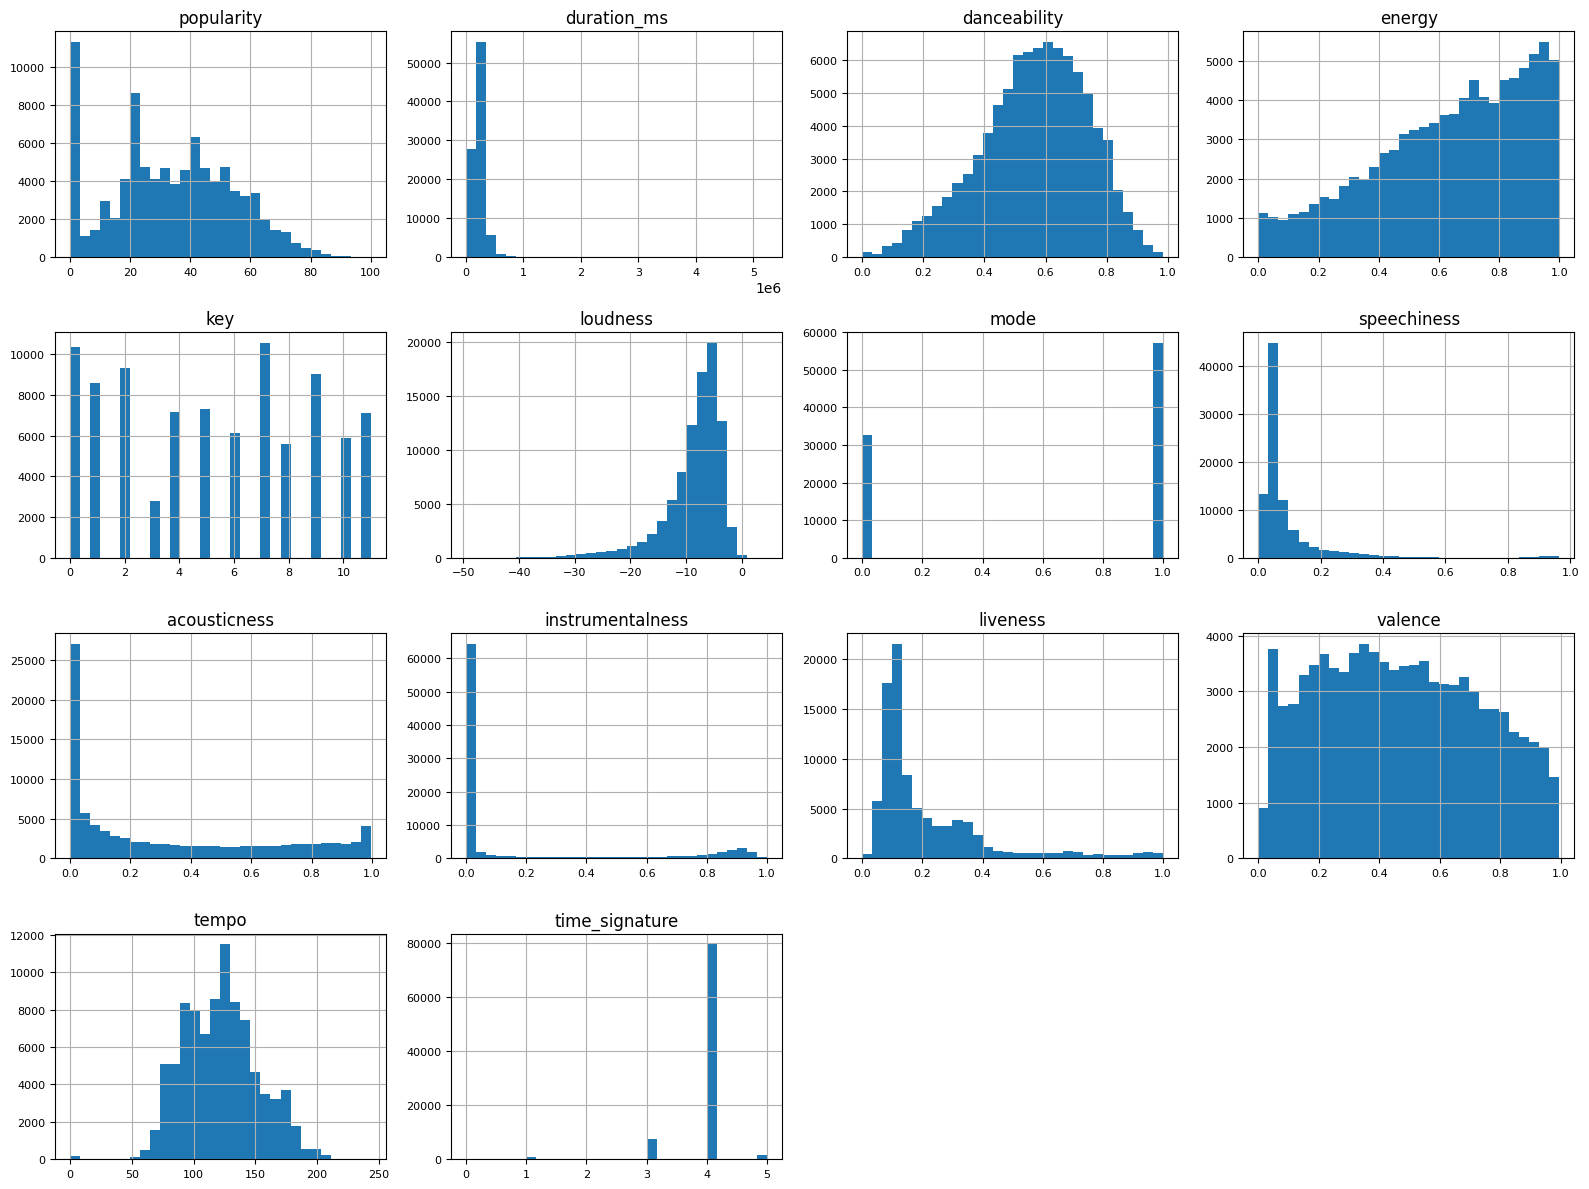

In [12]:
#Distribution of numerical columns
numerical_cols.hist(figsize=(16,12), bins=30, xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Duration in milliseconds (10 minutes = 600,000 ms, 1 minute = 60,000 ms)
df = df[(df['duration_ms'] <= 600000) & (df['duration_ms'] >= 60000)]

# Output the shape of the DataFrame after dropping the rows
print(f"The DataFrame now has {df.shape[0]} rows.")

The DataFrame now has 88419 rows.


In [14]:
# Drop rows with popularity less than 10
df = df[df['popularity'] >= 10]

# Output the shape of the DataFrame after dropping the rows
print(f"The DataFrame now has {df.shape[0]} rows.")

The DataFrame now has 74778 rows.


In [15]:
# # now analysing categorical columns
categorical_cols = df[df.columns[(df.dtypes == 'object') | (df.dtypes == 'bool')]]
categorical_cols.shape

(74778, 6)

In [16]:
categorical_cols.sample(5)

,track_id,artists,album_name,track_name,explicit,track_genre
72504,6TeB7j56k4AbELOl3G4zfj,Our Last Night;I See Stars;The Word Alive;Ashland,Someone You Loved,Someone You Loved,False,metalcore
35240,2vGEfLgpkfghd21SswawlB,Toca do Vale,Seu Polícia,Flores em Vida,False,forro
46138,0o9QbmX4o2eYF02Y5YoodT,Technikore,Not over Yet (Weaver vs. Steve Hill Mix) / Gim...,Gimme Some More,False,happy
43285,2ykddKlnrxzo8gAozmOTFT,Five Finger Death Punch,The Wrong Side Of Heaven And The Righteous Sid...,Dot Your Eyes,True,groove
14755,4wfqFX3MWgzceNnmEXAU4j,ChuChu TV,"ChuChuTV Nursery Rhymes & Songs for Children, ...",Colors Song for Children,False,children


In [17]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74778 entries, 0 to 113999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   track_id     74778 non-null  object
 1   artists      74778 non-null  object
 2   album_name   74778 non-null  object
 3   track_name   74778 non-null  object
 4   explicit     74778 non-null  bool  
 5   track_genre  74778 non-null  object
dtypes: bool(1), object(5)
memory usage: 3.5+ MB


In [18]:
df.describe(include=['object', 'bool'])

,track_id,artists,album_name,track_name,explicit,track_genre
count,74778,74778,74778,74778,74778,74778
unique,74778,28741,44203,65563,2,113
top,5SuOikwiRyPMVoIQDJUgSV,George Jones,The Complete Hank Williams,Alone,False,forro
freq,1,250,105,22,68202,997


In [19]:
explicit_trakes_prec = df['explicit'].sum()/df['explicit'].count()*100
print(f"Precentage of explicit tracks {explicit_trakes_prec:.2f}%")

Precentage of explicit tracks 8.79%


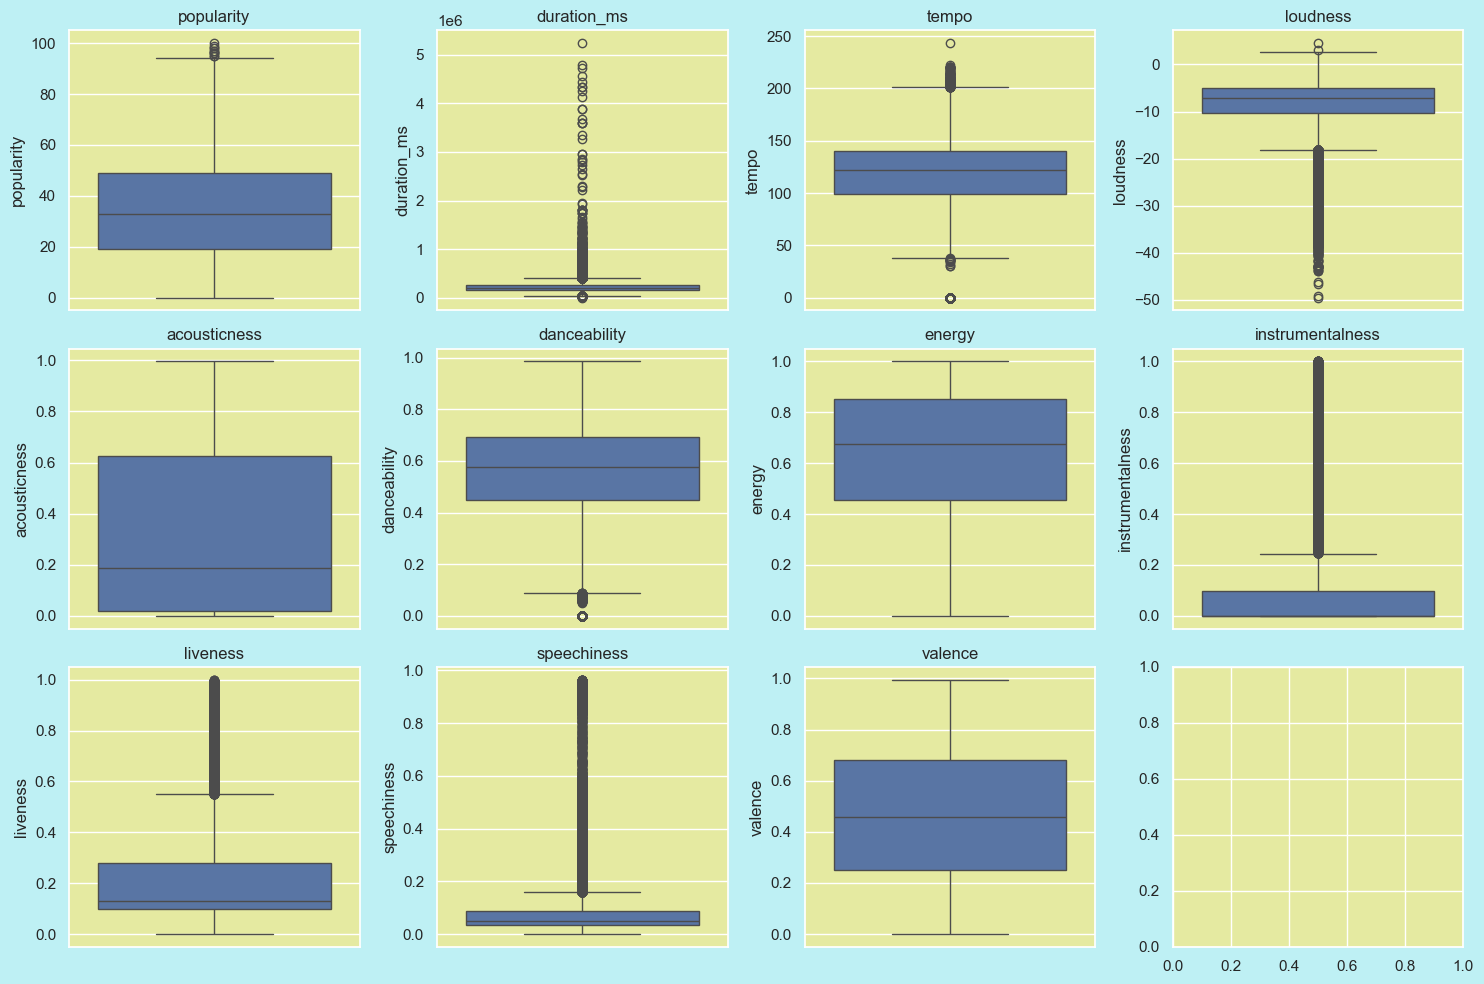

In [20]:
sns.set_style('darkgrid')
sns.set(rc={"axes.facecolor":"#E5EAA1","figure.facecolor":"#BEF0F4"})
columns = ['popularity', 'duration_ms', 'tempo', 'loudness', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))
for i, col in enumerate(columns):
    sns.boxplot(y=col, data=numerical_cols, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_title(col)
plt.tight_layout()
plt.show()

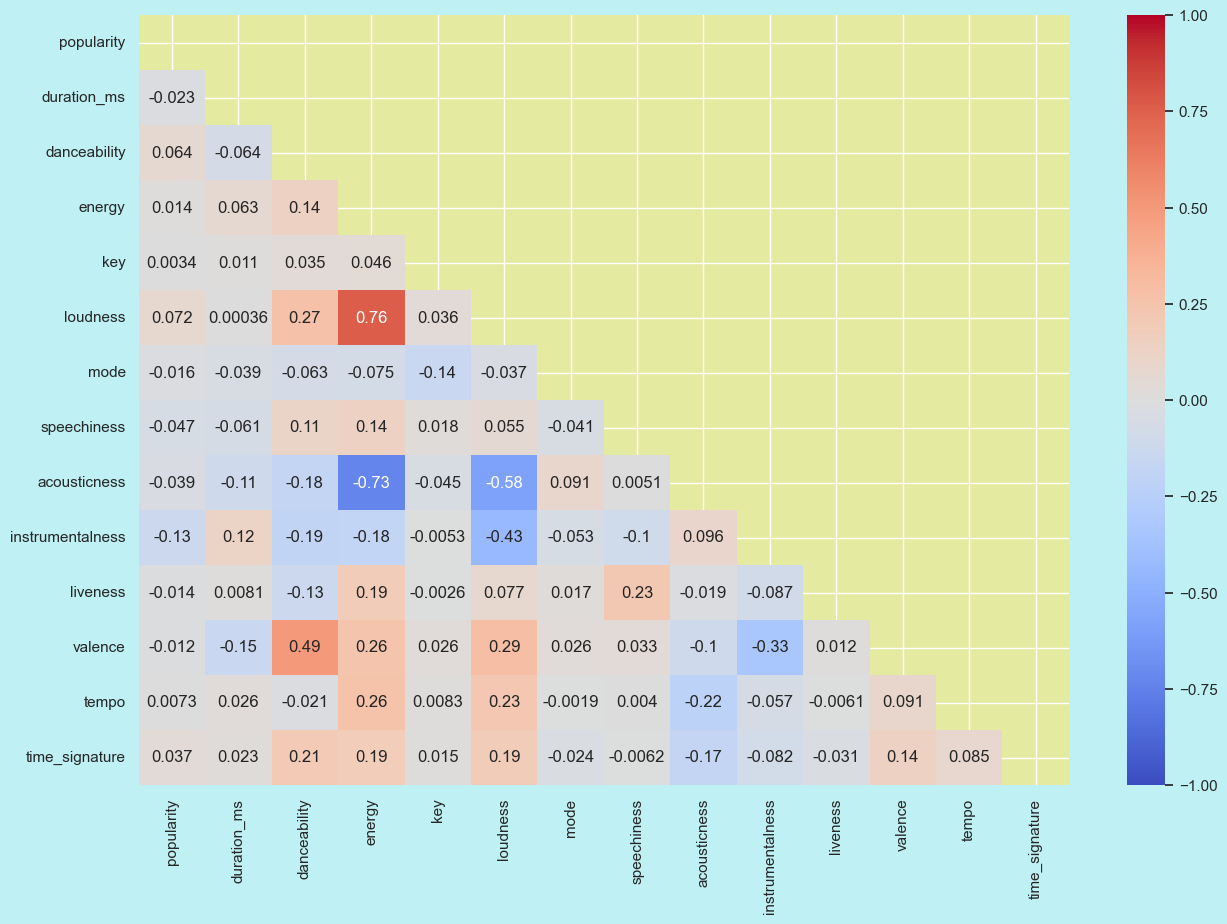

In [21]:
corr = numerical_cols.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.set_style('white')
sns.set(rc={"axes.facecolor":"#E5EAA1","figure.facecolor":"#BEF0F4"})
plt.figure(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, vmin=-1, vmax=1,cmap='coolwarm')
plt.show()

In [22]:
df = df.drop(['time_signature', 'key'], axis=1)

In [24]:
output_file = 'Project_data.csv'
df.to_csv(output_file, index=False)

In [25]:
df.shape

(74778, 18)

In [26]:
# Select relevant features for kNN
features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 
            'liveness', 'speechiness', 'instrumentalness']

# Extract and normalize the features
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df[features])

# Display the normalized feature data for verification
pd.DataFrame(normalized_features, columns=features).head()

,danceability,energy,valence,tempo,acousticness,liveness,speechiness,instrumentalness
0,0.686294,0.4610,0.718593,0.361245,0.032329,0.3580,0.148494,0.000001
1,0.426396,0.1660,0.268342,0.318397,0.927711,0.1010,0.079232,0.000006
2,0.444670,0.3590,0.120603,0.313643,0.210843,0.1170,0.057840,0.000000
3,0.270051,0.0596,0.143719,0.746758,0.908635,0.1320,0.037695,0.000071
4,0.627411,0.4430,0.167839,0.492863,0.470884,0.0829,0.054621,0.000000


In [27]:
df.shape

(74778, 18)

In [28]:
df['track_id'] = df.index
df['artists'] = df['artists'].astype(str)
df['album_name'] = df['album_name'].astype(str)
df['track_name'] = df['track_name'].astype(str)
df['track_genre'] = df['track_genre'].astype(str)

In [29]:
preprocessed_file_path = 'preprocessed_dataset.csv'
df.to_csv(preprocessed_file_path, index=False)

In [30]:
df.dtypes.to_frame('Data Type')

,Data Type
track_id,int64
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
loudness,float64


In [31]:
df.sample(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
72510,72510,I Prevail,TRAUMA,Deadweight,55,184333,True,0.509,0.968,-4.075,1,0.0802,0.000043,0.000043,0.353,0.370,104.970,metalcore
85920,85920,ZSK,Hallo Hoffnung,Die besten Lieder,34,150186,False,0.557,0.928,-4.033,1,0.0704,0.000245,0.000000,0.596,0.806,150.108,punk-rock
99509,99509,Camylio,i tried,i tried,66,160790,False,0.567,0.468,-9.630,0,0.1070,0.721000,0.000007,0.130,0.238,139.922,singer-songwriter
28204,28204,Krewella,Alibi,Alibi,42,215112,False,0.678,0.826,-4.663,0,0.0786,0.101000,0.000000,0.119,0.426,100.016,dub
6597,6597,Tiamat,The Musical History of Tiamat,Gaia - live in Stockholm 1994,19,383093,False,0.397,0.591,-8.146,0,0.0320,0.034300,0.519000,0.777,0.110,119.838,black-metal


In [36]:
from sklearn.neighbors import NearestNeighbors

# Fit the kNN model
k = 5  # Number of neighbors to consider
knn_model = NearestNeighbors(n_neighbors=k, metric='cosine')
knn_model.fit(normalized_features)

# Define a function to get song recommendations based on a given song index
def recommend_songs(song_index, num_recommendations=5):
    distances, indices = knn_model.kneighbors([normalized_features[song_index]], n_neighbors=num_recommendations + 1)
    recommendations = df.iloc[indices[0][1:]]  # Exclude the input song itself
    return recommendations[['track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

# Test the recommendation system with a sample song
sample_song_index = 31054  # Change this index to test with other songs
print(df.iloc[sample_song_index])
recommended_songs = recommend_songs(sample_song_index)
recommended_songs

track_id                                42765
artists                             Trap Them
album_name          Seizures in Barren Praise
track_name                     Guignol Serene
popularity                                 12
duration_ms                            119133
explicit                                False
danceability                            0.336
energy                                  0.991
loudness                               -3.799
mode                                        0
speechiness                             0.148
acousticness                         0.000013
instrumentalness                        0.022
liveness                                0.563
valence                                 0.285
tempo                                 113.283
track_genre                         grindcore
Name: 42765, dtype: object


,track_name,artists,album_name,track_genre,popularity
22458,The Black Sheep,Kataklysm,Of Ghosts and Gods,death-metal,49
82790,O.K. F.M. D.O.A.,Dillinger Four,Midwestern Songs Of The Americas,power-pop,23
22373,Jfc,The Acacia Strain,Continent,death-metal,24
22338,Ezekiel (The Visionary),For Today,Portraits,death-metal,26
72338,Prey,Parkway Drive,Reverence,metalcore,61


In [37]:
def recommend_by_song_name(song_name, num_recommendations=5):
    # Find the index of the song with the given name
    matches = df[df['track_name'].str.contains(song_name, case=False, na=False)]
    
    if matches.empty:
        return f"No matches found for song name: {song_name}"
    print(matches)
    # Use the first matching song for recommendations
    song_index = matches.index[0]
    print(f"Recommendations based on: {matches.iloc[0]['track_name']} by {matches.iloc[0]['artists']}")
    
    # Get recommendations
    return recommend_songs(song_index, num_recommendations)

# Test the function with a song name
song_name_input = "Sinking Stone"  # Replace with the desired song name
recommendations = recommend_by_song_name(song_name_input)
recommendations

      track_id                        artists      album_name     track_name  \
7671      7671  Alison Krauss & Union Station  Paper Airplane  Sinking Stone   

      popularity  duration_ms  explicit  danceability  energy  loudness  mode  \
7671          22       282586     False         0.514   0.347   -10.866     1   

      speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
7671       0.0296         0.815               0.0     0.277    0.386  159.562   

     track_genre  
7671   bluegrass  
Recommendations based on: Sinking Stone by Alison Krauss & Union Station


,track_name,artists,album_name,track_genre,popularity
36972,CDG,EDGE;Ratu$,EN LESSGUILL,french,32
104376,Ojos Tristes,Green Valley;Pure Negga;Rastachai,Ojos Tristes,spanish,31
69852,Jaiva Viplavam,Sha Bro,Jaiva Viplavam,malay,18
32543,Te Dejé una Carta,Clara Cava,Martes 13,electronic,38
33020,RIP Roach,XXXTENTACION;Ski Mask The Slump God,Revenge,emo,76


In [38]:
def recommend_by_track_id(track_id, num_recommendations=5):
    # Ensure the track_id is in the dataset index
    if track_id not in df.index:
        return f"No matches found for track ID: {track_id}"
    
    # Get recommendations using the track_id
    song_index = track_id  # Since track_id is now the same as the index
    print(f"Recommendations based on: {df.loc[song_index, 'track_name']} by {df.loc[song_index, 'artists']}")
    
    distances, indices = knn_model.kneighbors([normalized_features[song_index]], n_neighbors=num_recommendations + 1)
    recommendations = df.iloc[indices[0][1:]]  # Exclude the input song itself
    
    return recommendations[['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

# Test the function with a track ID
sample_track_id = 77  # Replace with your desired track ID
recommendations = recommend_by_track_id(sample_track_id)
print(recommendations)

Recommendations based on: The Long Road by Eddie Vedder;Nusrat Fateh Ali Khan
       track_id                    track_name                         artists  \
7336       7336              Tennessee Pusher          Old Crow Medicine Show   
7692       7692                Next Go 'Round          Old Crow Medicine Show   
40512     40512  Gerador Particular - Ao Vivo    Clayton Queiroz;Jessé Aguiar   
52453     52453        The Old Country Church  Webb Pierce;Anita Kerr Singers   
19919     19919            Mr. Tambourine Man                       Bob Dylan   

                      album_name track_genre  popularity  
7336            Tennessee Pusher   bluegrass          26  
7692            Tennessee Pusher   bluegrass          23  
40512         Gerador Particular      gospel          40  
52453             Songs of Faith  honky-tonk          13  
19919  Bringing It All Back Home     country          64  


In [35]:
def recommend_by_features(track_id, filter_by="genre", num_recommendations=5):
    """
    Recommend songs based on the features of a selected track and filter by genre, album, or artist.

    Parameters:
    - track_id (int): The track ID of the song to base recommendations on.
    - filter_by (str): The attribute to filter by ("genre", "album", or "artist").
    - num_recommendations (int): Number of recommendations to return.

    Returns:
    - DataFrame with recommended songs.
    """
    if track_id not in df.index:
        return f"No matches found for track ID: {track_id}"

    # Get recommendations using the track_id
    song_index = track_id  # Since track_id is now the same as the index
    print(f"Recommendations based on: {df.loc[song_index, 'track_name']} by {df.loc[song_index, 'artists']}")
   
    # Get details of the selected song
    selected_song = df.loc[track_id]
    filter_value = selected_song[filter_by]

    # Filter the dataset by the specified attribute
    filtered_data = df[df[filter_by] == filter_value]

    if filtered_data.empty:
        return f"No songs found with the same {filter_by} as the selected song."

    # Extract indices of the filtered data
    filtered_indices = filtered_data.index
    filtered_features = normalized_features[filtered_indices]

    # Fit kNN on the filtered dataset
    knn_model_filtered = NearestNeighbors(n_neighbors=num_recommendations + 1, metric="cosine")
    knn_model_filtered.fit(filtered_features)

    # Get recommendations within the filtered data
    song_index_in_filtered = list(filtered_indices).index(track_id)
    distances, indices = knn_model_filtered.kneighbors([filtered_features[song_index_in_filtered]], 
                                                        n_neighbors=num_recommendations + 1)
    
    recommended_indices = [filtered_indices[i] for i in indices[0][1:]]  # Exclude the input song itself
    recommendations = df.loc[recommended_indices]

    return recommendations[['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

# Test the function with a sample track ID and filter by genre
sample_track_id = 4  # Replace with your desired track ID
recommendations = recommend_by_features(sample_track_id, filter_by="track_genre",num_recommendations=5)
print(recommendations)

Recommendations based on: Hold On by Chord Overstreet
     track_id                            track_name               artists  \
896       896  Alone in the Dark Mansion of Madness            Harley Poe   
341       341                        Tell The World       Eric Hutchinson   
251       251                    Believe - Acoustic            John Adams   
272       272                                Arcade  Andrew Foy;Renee Foy   
613       613                          First & Last          Zack Tabudlo   

             album_name track_genre  popularity  
896           Horrorful    acoustic          26  
341        Pure Fiction    acoustic          58  
251  Believe (Acoustic)    acoustic          57  
272              Arcade    acoustic          37  
613             Episode    acoustic          49  


## Objective 3 : To Cluster Songs Based on Audio Features and Explore Genre Boundaries ##

In [2]:

import numpy as np 
import pandas as pd 
import math
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

## Getting the Data ##

In [3]:
df_music = pd.read_csv('spotify_dataset.csv')

In [4]:
# Drop first column
df_music.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [5]:
df_music.shape
# 114.000 rows and 20 columns

(114000, 20)

In [6]:
df_music.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Column Analysis
**Main Categorical Values**
* track_id : ID (key values, prioritize to be deleted), or what is the ID of the music
* artists : Who wrote the song?
* album_name : What album are they in?
* track_name : What is the name of the album?

**Other Categorical Values**
* key : What is the key the song is in? (Using Pitch Class Notation)
    * https://en.wikipedia.org/wiki/Pitch_class
    * If none found : -1
* time_signature : What is the time signature of the song? (In n/4, Most commonly are 4/4)
* track_genre : What is the genre of the music? (Target class)

**Numerical Values that have units Assigned to Them (BPM, milliseconds)**
* duration_ms : How long is the song duration? (In milliseconds, that is 0.001 of a second)
* loudness : How loud is the song? (In decibels, 0 is nothing, 140 is if I want to lit a cannon)
* tempo : How fast is the music? (in BPM (Beats per Minute))

**Numerical Values that do not a have unit**
* popularity : How popular is the song? (Based on how many times it's played, Between 0 to 100)
* danceability : How danceable is the song? (Between 0 (Moai statue) to 1 (Groovy, baby))
* energy : How loud or soft is the song? (Between 0 (Waltz) to 1 (Metal))
* speechiness : How common are the words in the song? (0 (silent) to 1 (yapping))
* acousticness : How acoustic is the song? (0 (no acoustic) to 1 (yes acoustic))
* instrumentalness : How vocalless is the music? (0 (Full of vocal) to 1 (no vocal))
    * Compare that to speechiness
* liveness : How much is the chance that there are some audience? (0 (no audience) to 1 (Live Aid concert))
* valence : How positive is the song? (0 (sad) to 1 (happy))
    * Compare that to mode

**Boolean (Or only have two values)**
* explicit : Is the track has explicit lyrics? (True = Yes; False = No or Unknown)
* mode : What is the modality of the song? (0 = minor, 1 for major)
    * I guess the major mode is the happier one and the minor mode is the sadder one?

I could either doing Classification in which I predict what is the genre of the music or doing Clustering and ignoring the track_genre

Update 30-9-2024 : Forget Classification, a music could have multiple genre, which would make Classification difficult. Try Clustering, grouping music based on their statistics
- Or, regression prediction on popularity, danceability, etc.

## Data Cleaning ##

In [7]:
# Drop general duplicates
df_music.duplicated().sum()
df_music.drop_duplicates(inplace = True)

In [8]:
# Missing Data
df_music.isna().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
df_music[df_music.isnull().any(axis = 1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [10]:
# Drop missing kpop song with Unknown
df_music.dropna(inplace = True)

In [11]:
# Missing Data
df_music.isna().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [12]:
# Duplicate dataset for later use
df_music_2 = df_music.copy()
df_music_later = df_music_2.copy()

In [13]:
df_music_2[df_music_2['track_id'].duplicated()].head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
3000,5E30LdtzQTGqRvNd7l6kG5,The Neighbourhood,Wiped Out!,Daddy Issues,87,260173,False,0.588,0.521,10,-9.461,1,0.0329,0.06780,0.149000,0.1230,0.337,85.012,4,alternative
3002,2K7xn816oNHJZ0aVqdQsha,The Neighbourhood,Hard To Imagine The Neighbourhood Ever Changing,Softcore,86,206280,False,0.575,0.568,9,-5.509,0,0.0300,0.04840,0.000417,0.2860,0.370,93.986,4,alternative
3003,2QjOHCTQ1Jl3zawyYOpxh6,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,-2.810,1,0.0336,0.04950,0.017700,0.1010,0.398,124.053,4,alternative
3011,6rrKbzJGGDlSZgLphopS49,The Score,ATLAS,Unstoppable,73,192106,False,0.485,0.843,1,-3.993,0,0.0467,0.00129,0.000010,0.1400,0.602,78.001,4,alternative
3012,0AUyNF6iFxMNQsNx2nhtrw,grandson,Blood // Water,Blood // Water,75,216720,False,0.510,0.882,8,-5.659,0,0.1590,0.00158,0.002060,0.0764,0.653,154.029,4,alternative


In [14]:
df_music_2.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [15]:
df_music_2['popularity'] = df_music_2.groupby(['track_id'])['popularity'].transform(lambda i : int(math.ceil(i.sum() / len(i))))
df_music_2.drop_duplicates(inplace = True)
df_music_2['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [16]:
# Find music that contains 2 or more genre tags
df_music_2.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


These are the music genres in the dataset
Generalizing music genre (Might be changing):
- EDM consists of ALL so-called 'techno' music
    - Club
    - Electro : (Electro, Breakbeat, Drum and Bass)
    - House : (House, Chicago House, Deep House, Garage, Dubstep, Progressive House)
    - Techno : (Techno, Detroit Techno, Hardcore, Hardstyle, IDM, Minimal Techno)
    - Trance
- Pop
    - Pop
    - Indie Pop
    - Power Pop
    - Synth-Pop
- Rock
    - Rock
    - Hard Rock
    - Industrial
    - Psych Rock
    - Rock n Roll
        - Rockabilly
    - Alt-Rock
        - Grunge
- Metal
    - Metal
    - Black Metal
    - Death Metal
    - Grindcore
    - Heavy Metal
    - Metalcore
- Punk
    - Punk
    - Punk Rock
    - Emo
    - Goth
- Brazil
    - Brazil
    - Forro
    - MPB
    - Pagode
    - Samba
    - Sertanejo
- Jamaica
    - Dancehall
    - Dub
    - Reggae
    - Reggaeton (Actually, it's from Panama, but it's derived from Reggae)
    - Ska
- China
    - Cantopop
    - Mandopop
- Country
    - Country
    - Bluegrass
    - Honky Tonk
- Japan
    - Japan
    - Anime
    - J-Dance
    - J-Idol
    - J-Pop
    - J-Rock

In [17]:
#Here i'm generalizing the genre tags to the comment above
replacement_dict = {
    'edm' : ['club', 'electro', 'breakbeat', 'drum-and-bass',
            'house', 'chicago-house', 'deep-house', 'garage',
            'dubstep', 'progressive-house', 'techno',
            'detroit-techno', 'hardcore', 'hardstyle',
            'idm', 'minimal-techno', 'trance'],
    'pop' :['indie-pop', 'power-pop', 'synth-pop'],
    'rock' :['hard-rock', 'industrial', 'psych-rock',
            'rock-n-roll', 'rockabilly', 'alt-rock',
            'grunge'],
    'metal' : ['black-metal', 'death-metal', 'grindcore',
              'heavy-metal', 'metalcore'],
    'punk' : ['punk-rock', 'emo', 'goth'],
    'latin' : ['forro', 'mpb', 'pagode', 'samba', 'sertanejo',
               'latino', 'tango', 'salsa', 'spanish', 'brazil'],
    'jamaica' : ['dancehall', 'dub', 'reggae', 'reggaeton',
                'ska'],
    'china' : ['cantopop', 'mandopop'],
    'country' : ['bluegrass', 'honky-tonk', 'blues', 'groove'],
    'japan' : ['anime', 'j-dance', 'j-idol', 'j-pop',
              'j-rock'],
    'children' : ['kids'],
    'jazz' : ['jazz', 'soul', 'r-n-b'],
    'funk' : ['funk', 'disco', 'hip-hop', 'trip-hop'],
    'ambient' : ['new-age'],
    'show-music' : ['disney', 'show-tunes', 'pop-film']
}

In [18]:
# Each genre has 1000 songs
# In the dataset with only duplicates song sans genre
# All 1000 songs of Singer-songwriter and also songwriter genre each is all in the said dataset
id_duplicated = df_music_2[df_music_2.drop('track_genre', axis = 1).duplicated()]['track_id'].copy()
df_music_double = df_music_2[df_music_2['track_id'].isin(id_duplicated)].copy()
print(len(df_music_double[df_music_double['track_genre'] == 'songwriter']))
print(len(df_music_double[df_music_double['track_genre'] == 'singer-songwriter']))

1000
1000


In [19]:
df_music_double['track_genre'].value_counts()

track_genre
songwriter           1000
singer-songwriter    1000
reggaeton             928
reggae                913
indie                 876
                     ... 
idm                     8
comedy                  7
sleep                   3
tango                   1
honky-tonk              1
Name: count, Length: 111, dtype: int64

In [20]:
# Dropping music with singer-songwriter and songwriter genre
df_music_3 = df_music_2[(df_music_2['track_genre'] != 'singer-songwriter') & (df_music_2['track_genre'] != 'songwriter')].copy()

In [21]:
df_music_3['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [22]:
# Generalizing music genre
for i in replacement_dict:
    for j in replacement_dict[i]:
        df_music_3.replace({'track_genre': j}, i, inplace = True)

In [23]:
df_music_3.duplicated().sum()

7743

In [24]:
df_music_3['track_genre'].unique()

array(['acoustic', 'afrobeat', 'rock', 'alternative', 'ambient', 'japan',
       'metal', 'country', 'latin', 'edm', 'british', 'china', 'children',
       'chill', 'classical', 'comedy', 'dance', 'jamaica', 'funk',
       'show-music', 'electronic', 'punk', 'folk', 'french', 'german',
       'gospel', 'guitar', 'happy', 'indian', 'pop', 'indie', 'iranian',
       'jazz', 'k-pop', 'malay', 'opera', 'party', 'piano', 'romance',
       'sad', 'sleep', 'study', 'swedish', 'turkish', 'world-music'],
      dtype=object)

In [25]:
df_music_3.drop_duplicates(inplace = True)

In [26]:
df_music_3.drop('track_genre', axis = 1).duplicated().sum()

14573

In [27]:
# Finding duplicated music only
id_duplicated = df_music_3[df_music_3.drop('track_genre', axis = 1).duplicated()]['track_id'].copy()
df_music_double = df_music_3[df_music_3['track_id'].isin(id_duplicated)].copy()
print(len(df_music_double[df_music_double['track_genre'] == 'sad']))

436


In [28]:
len(df_music_double)

26545

In [29]:
# Drop duplicated music with certain genre
drop_double = ['alternative', 'acoustic', 'children', 'chill',
              'comedy', 'dance', 'party', 'piano', 'romance',
              'sad', 'sleep', 'study', 'electronic', 'world-music',
              'british', 'french', 'german', 'indian', 'iran',
              'malay', 'swedish', 'turkish', 'show-music', 'guitar',
              'indie']
drop_genre_double = df_music_double[df_music_double['track_genre'].isin(drop_double)]['track_id'].copy()

In [30]:
drop_genre_double


0         5SuOikwiRyPMVoIQDJUgSV
1         4qPNDBW1i3p13qLCt0Ki3A
5         01MVOl9KtVTNfFiBU9I7dc
6         6Vc5wAMmXdKIAM7WUoEb7N
7         1EzrEOXmMH3G43AXT1y7pA
                   ...          
113572    1saXUvvFlAQaefZUFVmhCn
113605    1Q5jFp1g2Ns4gBsHRpcqhu
113617    71dLJx3qHOTQMTvvoE2dmd
113619    6OG5TBCmuTOuWCzSGsETrE
113641    7xsirhcgFWOnItsGuBfrv9
Name: track_id, Length: 6479, dtype: object

In [31]:
df_music_4 = df_music_3[df_music_3['track_id'].isin(drop_genre_double) == False].copy()
df_music_4.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.210,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.905,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.469,0.000000,0.0829,0.167,119.949,4,acoustic
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,1,0.0369,0.294,0.000000,0.1510,0.669,130.088,4,acoustic
10,4mzP5mHkRvGxdhdGdAH7EJ,Zack Tabudlo,Episode,Give Me Your Forever,74,244800,False,0.627,0.3630,8,-8.127,1,0.0291,0.279,0.000000,0.0928,0.301,99.905,4,acoustic


In [32]:
df_music_4['track_genre'].value_counts()

track_genre
edm            14767
latin           9461
rock            5964
metal           5305
country         4746
japan           4164
jamaica         3949
funk            3425
punk            2853
pop             2831
show-music      2511
jazz            2477
children        1921
china           1872
ambient         1724
gospel           999
afrobeat         999
happy            998
study            998
sleep            997
comedy           989
iranian          988
malay            980
opera            954
world-music      923
romance          904
turkish          878
k-pop            876
guitar           875
french           835
acoustic         833
party            818
classical        745
swedish          745
folk             738
piano            712
electronic       696
german           606
chill            587
british          584
sad              564
indian           549
dance            445
alternative      158
indie            121
Name: count, dtype: int64

In [33]:
# Combining genres
df_music_extra = df_music_4.copy()
df_music_extra['track_genre'] = df_music_extra.groupby(['track_id'])['track_genre'].transform(lambda i : ', '.join(i))
df_music_extra.drop_duplicates(inplace = True)

In [34]:
genre_list = df_music_extra['track_genre'].value_counts(ascending = True).copy()
genre_list

track_genre
japan, metal, rock        1
punk, edm, jamaica        1
punk, rock, edm           1
folk, pop, japan          1
folk, japan, jazz         1
                      ...  
country                3747
rock                   4574
metal                  4598
latin                  7648
edm                   12879
Name: count, Length: 269, dtype: int64

In [35]:
genre_list.tail(10)

track_genre
punk           2207
pop            2416
show-music     2511
funk           2583
japan          3437
country        3747
rock           4574
metal          4598
latin          7648
edm           12879
Name: count, dtype: int64

In [36]:
genre_list.head(199)

track_genre
japan, metal, rock       1
punk, edm, jamaica       1
punk, rock, edm          1
folk, pop, japan         1
folk, japan, jazz        1
                        ..
country, rock, metal    43
country, metal          45
japan, edm              45
country, jazz, rock     46
punk, opera             47
Name: count, Length: 199, dtype: int64

In [37]:
summer = 0
count = 0
for i in genre_list.index:
    summer += genre_list[i]
    count += 1
    if summer > 5000:
        break
print(summer, i, count)

5178 rock, metal 223


# Droping track_genre (Continuing from Data Cleaning)

To group music based on music dataset, I decided to drop the track_genre first and drop the duplicates then

In [38]:
df_music.drop('track_genre', axis = 1, inplace = True)
df_music.duplicated().sum()

23089

# Exploratory Data Analysis

## Main Categorical Values
- artists
- album_name
- track_genre
- key
- time_signature

In [39]:
# How many artists in the dataset?
len(df_music['artists'].unique())

31437

In [40]:
# Top 10 artists
pd.DataFrame(df_music['artists'].value_counts().head(10))

,count
artists,
The Beatles,279
George Jones,260
Stevie Wonder,235
Linkin Park,224
Ella Fitzgerald,221
Prateek Kuhad,217
Feid,201
Chuck Berry,190
Håkan Hellström,183


In [41]:
# How many albums in the dataset
len(df_music['album_name'].unique())

46589

In [42]:
# Top 10 albums
pd.DataFrame(df_music['album_name'].value_counts().head(10))

,count
album_name,
Alternative Christmas 2022,195
Feliz Cumpleaños con Perreo,180
Metal,143
Halloween con perreito,122
Halloween Party 2022,114
The Complete Hank Williams,110
Fiesta portatil,108
Frescura y Perreo,106
Esto me suena a Farra,105


<Axes: xlabel='key', ylabel='count'>

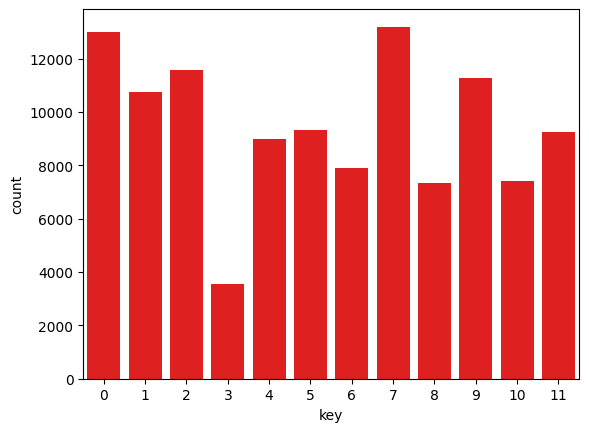

In [43]:
# A key in music is a group of notes that forms the basis of a music
# https://en.wikipedia.org/wiki/Key_(music)
# 
# Key distribution
sns.countplot(df_music, x = 'key', color = 'red')

C:\Users\user\AppData\Local\Temp\ipykernel_20864\3554680511.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.countplot(df_music, x = 'key', palette = piano, linewidth = 2, edgecolor = 'black')
C:\Users\user\AppData\Local\Temp\ipykernel_20864\3554680511.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  graph.set_xticklabels([


[(13858.95, 0.0)]

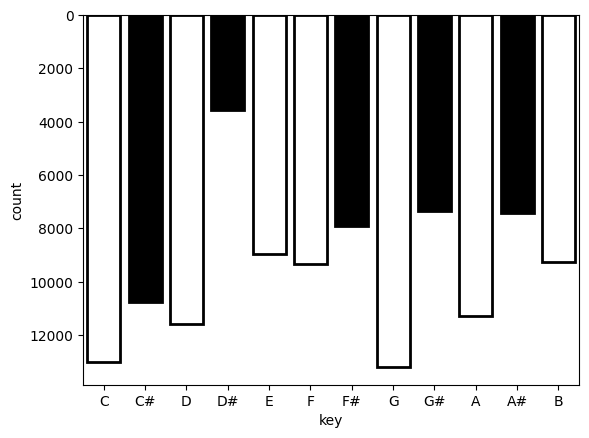

In [44]:
# Key distribution with tonal letters
# Also, with a piano plot
piano = ['black' if i in [1, 3, 6, 8, 10] else 'white' for i in range(0, 12)]

graph = sns.countplot(df_music, x = 'key', palette = piano, linewidth = 2, edgecolor = 'black')
graph.set_xticklabels([
    'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'
])
graph.set(ylim = graph.get_ylim()[::-1])

<Axes: xlabel='time_signature', ylabel='count'>

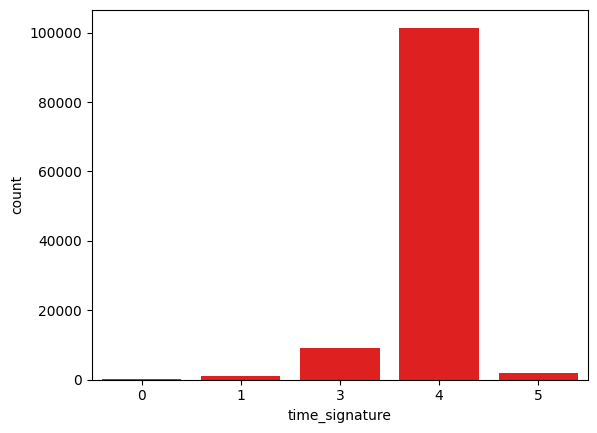

In [45]:
# Plotting to The Time Signature of Songs in the Dataset
sns.countplot(df_music, x = 'time_signature', color = 'red')

In [46]:
#Displaying the Songs with a Heat Signature of 0 (Zero)
df_music[df_music['time_signature'] == 0].head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2926,0jdfbvSdaWvxfAlD20TtNc,Yaşlı Amca,Akşamüstü,Sanki Yapamadım,44,213198,False,0.442,0.5670,8,-6.346,0,0.0516,0.238,0.000325,0.0852,0.639,138.616,0
4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,Voyager - Essential Max Richter,The Departure,64,151506,False,0.000,0.0362,0,-22.519,0,0.0000,0.994,0.940000,0.0958,0.000,0.000,0
4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,Jane Eyre - Original Motion Picture Soundtrack,The End of Childhood (feat. Jack Liebeck),55,73266,False,0.000,0.0445,0,-26.440,0,0.0000,0.972,0.972000,0.0873,0.000,0.000,0
4664,1Kb2DqjHRvOcT5xeWtz3t5,Sylvain Chauveau,Des Plumes Dans La Tête,Ferme Les Yeux,53,68493,False,0.000,0.0323,2,-23.636,0,0.0000,0.994,0.973000,0.0922,0.000,0.000,0
26910,7HSc2wpHlXKIl8SCZK7zsP,Benny Martin,Here Comes the Sun (Piano Instrumental),Here Comes the Sun (Piano Instrumental),18,203705,False,0.329,0.0607,9,-28.310,1,0.0507,0.994,0.880000,0.0858,0.421,93.948,0


In [47]:
df_music['time_signature'].value_counts() / len(df_music)


time_signature
4    0.893764
3    0.080388
5    0.015896
1    0.008516
0    0.001436
Name: count, dtype: float64

### apparently, time_signature is too imbalanced ###
### Therefore this column would be deleted later. ###

## Valued Numerical
- duration_ms (in milliseconds, or 0.001 of a second)
- loudness (in decibels)
- tempo (in BPM (Beats per minute))

### What I found
* A song has the average lenght of 229.141 seconds, or 3 minutes and 49 seconds and has the average bpm of 122.06 beats per minute
* There's a song that has 0 lenght and also 0 beats per minute
* The longest song is 5237.295 seconds, or 87 minutes, 17 seconds
* There would be more extensive explanation for loudness

In [48]:
df_music[['duration_ms', 'loudness', 'tempo']].describe()

,duration_ms,loudness,tempo
count,1.135490e+05,113549.000000,113549.000000
mean,2.280814e+05,-8.243408,122.175745
std,1.064131e+05,5.011422,29.972954
min,8.586000e+03,-49.531000,0.000000
25%,1.741840e+05,-9.998000,99.296000
50%,2.130000e+05,-6.997000,122.020000
75%,2.615880e+05,-5.001000,140.074000
max,5.237295e+06,4.532000,243.372000


- https://en.wikipedia.org/wiki/Decibel
- https://en.wikipedia.org/wiki/Sound_intensity
- The loudness of the sound is calculated using decibel
- A decibel is equals to 20 log10(I (the sound intensity) / I0 (the base intensity))
- I0 is the lowest sound a human can hear, which is 10^-12 Watt per square meter
- Watt per square meter is how much is the power (watt) received (by ear) to a 1 square meter

- I'm turning the loudness in dataset from decibel to Watt per square meter
- With the formula of I0 * 10^(loudness (db)/20)
- Which is just equals to 10^((loudness/20)) picoWatt per square meter

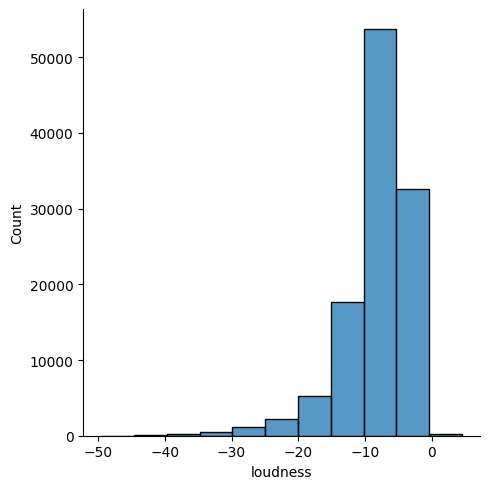

In [49]:
# Loudness distribution in decibel
sns.displot(df_music['loudness'], binwidth = 5)

In [50]:
# Turning loudness from decibel to picoWatt per meter square
df_music['loudness'] = pow(10, df_music['loudness']/20)

In [51]:
# top 10 loudest song
df_music.sort_values('loudness', ascending = False).head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
17574,0HfHtjS9S9q4DGVC3uIIRB,Five Star Hotel,Gray Data,Fate Dance,16,237000,False,0.310,0.999,4,1.685000,0,0.3430,0.000102,0.945000,0.1480,0.0333,160.040,4
59225,5rm5Zqktf6v3u9yGj6RR5W,Najand,In the Night of Revolution,Islamic Capitalism,0,60056,False,0.149,0.868,3,1.438136,0,0.0767,0.191000,0.865000,0.6250,0.0494,136.188,3
38840,7K0pkS5lqUkFd9kuY0spiK,The Red Pears,We Bring Anything to the Table... Except Table...,Time Bomb,25,176065,False,0.442,0.800,4,1.344931,1,0.0686,0.262000,0.000001,0.6640,0.3690,118.053,4
59337,1VHxmBxtPxLmI5Ffb8W35O,Najand,In the Night of Revolution,A Better World Is Possible,0,60056,False,0.244,0.499,2,1.239367,1,0.0794,0.241000,0.718000,0.8010,0.0347,99.663,3
37738,0t35f7eKjuLqXfidSEvDL2,DJ BRUNO PRADO,TIPO HARIEL - SEI QUE E RARIDADE -,TIPO HARIEL - SEI QUE E RARIDADE -,44,203076,True,0.951,0.987,0,1.233247,0,0.3630,0.611000,0.000033,0.1030,0.6740,130.005,4
17895,4sLrEAfwvFAkaL1kwHmvPC,Free Refills,Raw Steak Black Coffee,Malfunction,15,116804,False,0.384,0.955,2,1.229561,1,0.0851,0.003120,0.603000,0.0542,0.8880,187.112,4
59833,19ODdY2U4Wqlv6t04dk54j,Najand,In the Night of Revolution,Preaching for the Deaf,0,192407,False,0.211,0.975,7,1.216186,0,0.1070,0.155000,0.000256,0.3570,0.0503,131.265,5
37548,6y3vYl2F0OnUwmKxPF6TA1,DJ Arana,ROCK PESADO,AUTOMOTIVO DAS PIRANHA - VEM COMER MINHA TCHEC...,47,200020,True,0.758,0.985,1,1.213668,1,0.4250,0.647000,0.000000,0.2430,0.4900,130.924,4
17788,25Ff6JPWUkl786IQeCkcCc,Free Refills,Raw Steak Black Coffee,The Mall,16,113741,True,0.504,0.982,3,1.212411,0,0.2040,0.001540,0.293000,0.2400,0.9150,153.030,4
69699,2RCsqMmOl95kCPGxU1DZec,Sujatha,Hits of A.R.Rahman Nenjame,"Mel Nattu Isai (From ""Jodi"")",22,70885,False,0.638,0.907,4,1.177064,0,0.0487,0.284000,0.000000,0.3680,0.5940,112.972,4


In [52]:
# Top 10 softest song
df_music.sort_values('loudness').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
101888,5utUKeJ2ZG9KCZbvdEzPfa,White Noise Sleep Sounds,Soothing White Noise,Soothing White Noise - Loopable With No Fade,32,65248,False,0.000,0.000687,10,0.003338,0,0.0000,0.908,0.94300,0.1010,0.00000,0.000,0
101538,0jZmx4t0Fg4SJxJj0jnAdU,White Noise Sleep Sounds,Soothing White Noise,White Noise - Loopable With No Fade,37,74217,False,0.000,0.003320,10,0.003425,0,0.0000,0.910,0.84900,0.1010,0.00000,0.000,0
101722,5B9ZSS4Xd7d0WTdRjG0fJh,Atmosphere Asmr,Fan Sounds & White Noise 2 (Deluxe Edition),Ceiling Fan Sound on Low Power,34,120000,False,0.162,0.004830,6,0.004682,0,0.0507,0.924,0.96500,0.1100,0.03270,138.768,4
101360,6UT7KpL0wkYVBNSydJFCSi,White Noise for Babies;Crickets;Baby Sleep Sounds,Cricket Sounds,Cricket Sound 4 - Loopable With No Fade,54,71000,False,0.461,0.003250,10,0.004869,0,0.0639,0.915,0.86200,0.0594,0.07280,111.653,4
79719,4NSH5KlrNzdH9OBtgsBFpL,Lazar Berman,Inedito (Unpublished),Chaconne in sol maggiore : Variazione 9,58,63840,False,0.387,0.001810,7,0.006341,0,0.0632,0.995,0.91900,0.0996,0.47500,98.691,4
101972,0zoh2CMrXK1LtHD38McuxR,Binaural Beats;White Noise Babies;Binaural Bea...,Airconditioner Noise,Nap in the Afternoon Box Fan,32,60000,False,0.188,0.414000,1,0.006351,0,0.0720,0.996,0.99800,0.1030,0.00994,136.862,4
101968,5Umbl1Z7YwhfxbxFglKbYB,Relaxing Music Therapy;4D Nature Recordings;Cr...,Night Crickets for Babies,Loopable Woods,32,99778,False,0.381,0.086000,9,0.006521,1,0.0459,0.197,0.93300,0.1830,0.04000,137.552,3
101476,1umAjZ6wVUjZIEOAeeULag,Wave Sounds For Sleep,Wave Sounds For Baby Sleep,Sleep Sound For Babies - Underwater,36,139661,False,0.244,0.145000,10,0.006680,0,0.0494,0.970,0.88800,0.0926,0.16200,138.094,4
79591,4xTvAj3iYFWOoeaErsNwbj,Brian Lyndon,Wake with me,Wake with me,60,135647,False,0.277,0.001760,0,0.006837,1,0.0485,0.990,0.94500,0.1030,0.07950,110.541,4
101397,6BB2d2tQcyBfkxOmayHYXM,White Noise Babies;White Noise For Baby Sleep,Loopable White Noise,Clean White Noise - Loopable With No Fade - Wh...,39,67682,False,0.000,0.000020,10,0.007042,1,0.0000,0.974,0.00105,0.1010,0.00000,0.000,0


<Axes: xlabel='loudness', ylabel='Count'>

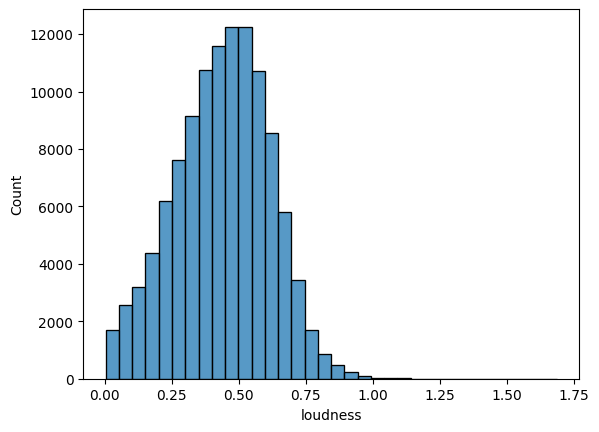

In [53]:
# Loudness distribution in picoWatt per meter square
sns.histplot(df_music['loudness'], binwidth = 0.05)

<Axes: xlabel='loudness', ylabel='Count'>

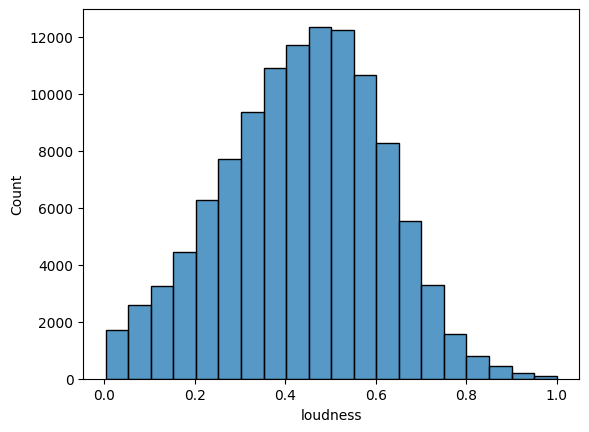

In [54]:
# Loudness distribution less 10^-12 picoWatt per meter square
sns.histplot(df_music[df_music['loudness'] < 1]['loudness'], binwidth = 0.05)

In [55]:
# Top 10 longest song
df_music.sort_values('duration_ms', ascending = False).head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
73617,3Cnz3Bu9Wcw8p3kiBTXTxp,Tale Of Us,Unity (Voyage Mix),Unity (Voyage Mix) Pt. 1,35,5237295,False,0.6950,0.736,5,0.270054,0,0.0374,0.00399,0.8600,0.0910,0.05090,124.001,4
10935,0LBIf9EFHuxmuNig4JHGZo,Timo Maas,Crossing Wires 002 - Compiled And Mixed By Tim...,Crossing Wires 002 - Continuous DJ Mix,11,4789026,False,0.6970,0.632,1,0.237985,1,0.0451,0.00815,0.8710,0.0998,0.15100,121.055,4
24348,6wypxnAvmv5zYewUX3VFDd,Seth Troxler,Seth Troxler - The Lab 03,The Lab 03 - Continuous DJ Mix Part 1,8,4730302,False,0.6840,0.656,5,0.276599,0,0.0633,0.01910,0.8480,0.1030,0.30100,123.180,4
73840,6JbQr97EMFD2D3Ek6gxgt1,Loco Dice,Amnesia Ibiza - Underground 10,Amnesia Ibiza Underground 10 DJ Mix,17,4563897,False,0.7830,0.728,10,0.309885,0,0.0612,0.00158,0.8400,0.1580,0.18900,125.044,4
13344,3gFme8BdfTtFHxKmuTnSbj,Mark Farina,House of OM (DJ Mix),House of Om - Mark Farina - Continuous Mix,11,4447520,False,0.8610,0.805,11,0.475281,0,0.0711,0.00548,0.5770,0.1350,0.54500,129.306,4
13245,13hQAhg1owjTpTcI9xQc6c,Mark Farina,Live In Tokyo,Live In Tokyo - Continuous Mix,11,4339826,False,0.8060,0.582,1,0.246008,1,0.0874,0.00830,0.2370,0.3280,0.68600,128.368,4
13195,3se0UYprtkHthJEBuk1A5K,Mark Farina,Greenhouse Construction,Greenhouse Construction,12,4334721,False,0.8460,0.744,10,0.344350,0,0.0611,0.00371,0.3350,0.3130,0.53200,125.434,4
27926,6eTDnsdPlRUyrTHqFj3l7W,Lenzman;Dan Stezo,NQ State of Mind,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",15,4246206,True,0.5930,0.924,1,0.632485,1,0.0899,0.00369,0.0221,0.5340,0.24200,173.938,4
101390,2QfFLpSGF1T1pY6tq4kD7Z,Ocean Sounds,Ocean Waves Sounds to Relax and Sleep,Ocean Waves Sounds,39,4120258,False,0.0797,0.995,1,0.135223,1,0.0612,0.93200,0.5620,0.3100,0.00001,84.788,3
45063,0PINNy1r5eEILOuHpnjl5d,Estas Tonne,Internal Flight (Remastered),Internal Flight (Remastered),47,3876276,False,0.3000,0.640,4,0.344112,0,0.0367,0.94600,0.8930,0.0783,0.21200,159.624,4


In [56]:
# top 10 shortest song
df_music.sort_values('duration_ms').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
59310,6hsyfegVY5yklJneM40mWi,Leila Bela,Angra Manyu,The Exorsism Begins...,0,8586,False,0.000,0.0400,8,0.032681,0,0.0000,0.928,0.9560,0.115,0.000,0.000,0
59812,38Ogh3rsHba83kXx13gbKs,Leila Bela,Angra Manyu,V-4,0,13386,False,0.000,0.2240,11,0.077660,1,0.0000,0.970,0.0000,0.907,0.000,0.000,0
59775,1HVjSh7scH1PaPiLjy2LEu,Leila Bela;Leila's Opera Class,Angra Manyu,Screams for a Finale! (feat. Leila's Opera Class),0,15800,False,0.251,0.5080,5,0.296347,0,0.3160,0.969,0.9990,0.952,0.000,184.051,3
16856,5YKCM3jbJ8lqUXUwfU7KwZ,Wolfgang Amadeus Mozart;Ingrid Haebler,Mozart: The Complete Piano Sonatas,"Andante in C Major, K. 1a",0,17453,False,0.467,0.0301,2,0.037506,0,0.0428,0.995,0.9000,0.124,0.000,84.375,4
39233,1T5QvLF9lO4HO3OZQbaX9p,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,0.143186,1,0.0370,0.985,0.9210,0.164,0.912,89.032,1
16288,1T5QvLF9lO4HO3OZQbaX9p,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,0.143186,1,0.0370,0.985,0.9210,0.164,0.912,89.032,1
59306,3qSaeaXmtOuzkqe7DKgoiM,Leila Bela,Angra Manyu,V-7,0,21120,False,0.229,0.0577,8,0.039994,0,0.1960,0.626,0.9310,0.108,0.253,172.897,4
59609,1oVrTBrCsM2eTE1G50yxY9,Leila Bela,Angra Manyu,Shatter,0,21240,False,0.424,0.8690,9,0.390481,0,0.0728,0.707,0.0893,0.117,0.000,135.107,4
11398,1egJZfc8JBT2blFQ4clPKe,Benjamin Britten;Steven Isserlis,October Classical Playlist,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",0,22266,False,0.335,0.0593,11,0.048056,0,0.0430,0.992,0.8690,0.116,0.195,77.266,5
16292,5viwzFJxwRE1OEUR7G6hiD,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 13, Estrella (Live in Jap...",0,23506,False,0.379,0.2370,5,0.122110,1,0.0470,0.993,0.8870,0.144,0.477,116.093,4


<Axes: xlabel='duration_ms', ylabel='Count'>

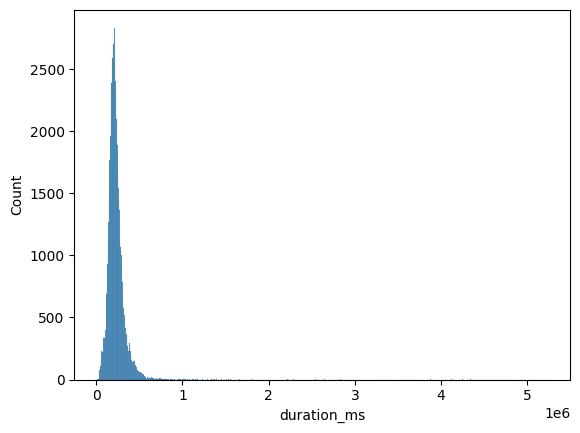

In [57]:
# Music duration distribution
sns.histplot(df_music['duration_ms'])
# Need log scale

In [58]:
# top 10 fastest song
df_music.sort_values('tempo', ascending = False).head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
8619,55ROr3cl3yi4YRBgfpDy1d,J.J. Cale,Naturally,Call The Doctor,59,147200,False,0.466,0.188,1,0.121493,0,0.0547,0.198000,0.657000,0.0820,0.6150,243.372,3
111908,25G1w3E4OMrovtPE5F510g,Portishead,Portishead,Undenied,46,260026,False,0.241,0.281,0,0.366185,1,0.0416,0.450000,0.000007,0.0937,0.0321,222.605,3
26681,3Qq52P28qQHcFXZeoQmNSm,Billboard Baby Lullabies,Lullaby Renditions of Winnie the Pooh,Hip Hip Pooh Rah,20,88641,False,0.244,0.323,0,0.114340,1,0.0464,0.968000,0.947000,0.1430,0.3590,220.525,4
26638,1FUCKL0Q7UZBz3J1eUjSbJ,Billboard Baby Lullabies,Lullaby Renditions of Winnie the Pooh,Heffalumps and Woozles,20,108777,False,0.225,0.257,0,0.141368,0,0.0443,0.992000,0.901000,0.1650,0.2950,220.084,4
1144,2mvXJ9JNoxuX50uT2mLHhN,Hugh Masekela,Best Afrobeat Tunes,Makoti,0,274933,False,0.469,0.824,8,0.288902,1,0.0944,0.478000,0.268000,0.0760,0.7810,220.081,4
1136,6w1T511GDmnHWF1EqqZm2y,Hugh Masekela,Afropop 2022,Makoti,0,274933,False,0.469,0.824,8,0.288902,1,0.0944,0.478000,0.268000,0.0760,0.7810,220.081,4
1087,6M0dUj7G1BBsFRUZVGFyma,Hugh Masekela,Africa Rising Vol.3,Makoti,0,274933,False,0.469,0.824,8,0.288902,1,0.0944,0.478000,0.268000,0.0760,0.7810,220.081,4
94759,1nsSTfcy0hjSf5TQ7m5kD4,Dendipappey,Goodbye to a world,Goodbye to a world,52,192078,False,0.657,0.209,7,0.249259,1,0.0971,0.977000,0.938000,0.0984,0.5110,220.039,4
59251,75ffZ9B8EmTtqoh9vdgeVq,Crows in the Rain,"You Walked with Me Then, Before Night or Day",When There Was Nothing,3,391296,False,0.319,0.139,4,0.053592,0,0.0367,0.927000,0.903000,0.0808,0.0393,219.971,3
10195,61TE609sILpyLH3Q4aEDH2,Krafty Kuts;Krossbow,Feel Like Jumpin,Feel Like Jumpin - Krossbow Remix,17,296000,False,0.498,0.737,0,0.464783,1,0.0435,0.000051,0.767000,0.0351,0.3420,219.693,4


In [59]:
# top 10 slowest song
df_music.sort_values('tempo').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
101598,7nOk0pfj4DqDglEjgaJ0EG,Weißes Rauschen HD,"Weißes Geräusch Für Tiefen Schlaf, Tinnitus Un...",Weißes Rauschen: Entspannende Stimmungen,35,88229,False,0.0,0.000267,1,0.070632,1,0.0,0.926000,0.345,0.1740,0.0,0.0,0
101589,4xGBr91n9vWRweKI0hd3u2,Rain Sounds,Rainfall,Spa Rain,35,97219,False,0.0,0.007430,8,0.101146,1,0.0,0.000001,0.807,0.4140,0.0,0.0,0
101591,53z8ah9wlzvII7pnmmjBJX,Granular,Pink Noise For Sleep,Pink Noise For Sleep 5,36,103177,False,0.0,0.653000,10,0.045368,1,0.0,0.985000,0.227,0.1110,0.0,0.0,0
101595,5V8TEDGMTyYx8nBFz94C0a,Weißes Rauschen HD,"Weißes Geräusch Für Tiefen Schlaf, Tinnitus Un...",Weißes Rauschen: Löschen Sie Den Geist,35,101120,False,0.0,0.000088,0,0.059245,1,0.0,0.823000,0.553,0.3880,0.0,0.0,0
101597,4HulNbrL7VILLuHV9tsADy,Weißes Rauschen HD,"Weißes Geräusch Für Tiefen Schlaf, Tinnitus Un...",Weißes Rauschen: Aufwachen Total Entspannt,35,105770,False,0.0,0.000080,10,0.020590,1,0.0,0.977000,0.988,0.1100,0.0,0.0,0
101616,7LVTRCPF8OeR35VexfK1XO,Loopable,Loopable Ambience of Brown Noise and Brown Waves,Brown Noise Waves,35,93451,False,0.0,0.000020,1,0.115478,1,0.0,0.113000,0.940,0.3630,0.0,0.0,0
101617,7aqkiFyBFMmJPIT0hkY4MK,Loopable,Loopable Ambience of Brown Noise and Brown Waves,Pure Brown Noise - Loopable with no fade,34,71397,False,0.0,0.000020,10,0.133321,0,0.0,0.000000,0.124,0.6880,0.0,0.0,0
101619,63gkPI6zuRKPAfvfkZ2U1s,Sleep Baby Sleep;Soothing White Noise for Slee...,"Loopable Fans, Air Conditioner, and an Office ...",Home Air Filterer Unit,35,75980,False,0.0,0.003800,1,0.046345,1,0.0,0.000055,0.144,0.1170,0.0,0.0,0
101621,5qVRWUq8ECJaWTx2rE2kUD,Sleep Baby Sleep;White Noise Babies;White Nois...,"Soothing Brown Noise, Brown Waves and other Am...",Soothing Brown Noise Waves,35,93451,False,0.0,0.000020,1,0.115478,1,0.0,0.113000,0.940,0.3630,0.0,0.0,0
101631,517zFFE01WR7zuNONic10C,White Noise Babies;White Noise for Babies,Loopable White Noise,Air Conditioner - Loopable With No Fade (feat....,34,77482,False,0.0,0.000638,1,0.007191,1,0.0,0.980000,0.833,0.0983,0.0,0.0,0


<Axes: xlabel='tempo', ylabel='Count'>

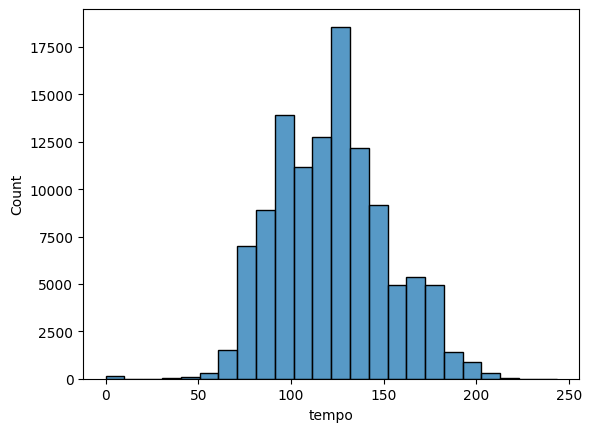

In [60]:
sns.histplot(df_music['tempo'], binwidth = 10)


In [61]:
# I noticed that there's an uptick on 0 (or near 0) tempo and that might be an outlier

In [62]:
df_music[['duration_ms', 'loudness', 'tempo']].describe()

,duration_ms,loudness,tempo
count,1.135490e+05,113549.000000,113549.000000
mean,2.280814e+05,0.437272,122.175745
std,1.064131e+05,0.176543,29.972954
min,8.586000e+03,0.003338,0.000000
25%,1.741840e+05,0.316301,99.296000
50%,2.130000e+05,0.446838,122.020000
75%,2.615880e+05,0.562277,140.074000
max,5.237295e+06,1.685000,243.372000


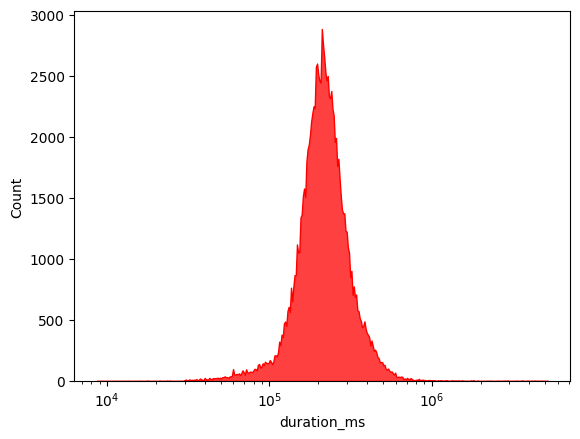

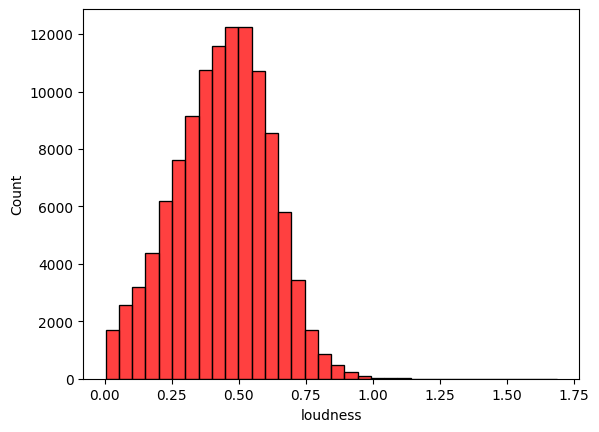

<Axes: xlabel='tempo', ylabel='Count'>

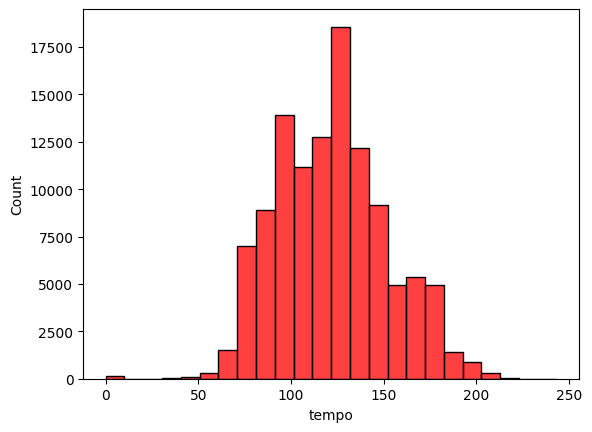

In [63]:
sns.histplot(df_music['duration_ms'], log_scale = True, element = 'poly', color = 'red')
plt.show()
sns.histplot(df_music['loudness'], binwidth = 0.05, color = 'red')
plt.show()
sns.histplot(df_music['tempo'], binwidth = 10, color = 'red')

## Numerical Values in the Dataset Explained
* popularity : How popular is the song? (Based on how many times it's played, Between 0 to 100)
    * I'm not counting popularity in the dataset
    * Because popularity scored after the music is created
* danceability : How danceable is the song? (Between 0 (Moai statue) to 1 (Groovy, baby))
* energy : How loud or soft is the song? (Between 0 (Waltz) to 1 (Metal))
* speechiness : How common are the words in the song? (0 (silent) to 1 (yapping))
* acousticness : How acoustic is the song? (0 (no acoustic) to 1 (yes acoustic))
* instrumentalness : How vocalless is the music? (0 (Full of vocal) to 1 (no vocal))
    * Compare that to speechiness
* liveness : How much is the chance that there are some audience? (0 (no audience) to 1 (Live Aid concert))
* valence : How positive is the song? (0 (sad) to 1 (happy))
    

In [64]:
non_unit_num = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']

<Axes: xlabel='speechiness', ylabel='instrumentalness'>

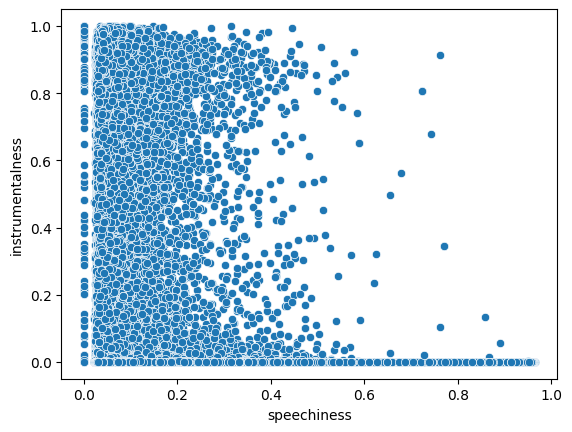

In [65]:
# Comparing speechiness and instrumentalness
# Accorind to the Scatter Plot there is No Correlation
sns.scatterplot(df_music, x = 'speechiness', y = 'instrumentalness')

In [66]:
df_music[non_unit_num].describe()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
count,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,0.567031,0.642091,0.084674,0.314064,0.155703,0.213613,0.474205
std,0.173409,0.251053,0.105762,0.331906,0.309217,0.190462,0.259204
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.456000,0.473000,0.035900,0.016800,0.000000,0.098000,0.260000
50%,0.580000,0.685000,0.048900,0.168000,0.000041,0.132000,0.464000
75%,0.695000,0.854000,0.084500,0.596000,0.048700,0.273000,0.683000
max,0.985000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000


In [67]:
# Function to show multiple distribution plots
def multiplotter(col, row, size, column_name, df):
    # Numbers and size of plots
    fig, ax = plt.subplots(ncols = col, nrows = row, figsize = size)

    # Initializing subplot position
    x = 0
    y = 0

    # Looping several subplots of distribution charts
    for i in column_name:
        sns.histplot(df[i], binwidth = 0.05, color = 'red', ax = ax[x,y])
        print(x, y)
        x += 1 # Move to the right
        if x == row: # Move below
            x = 0
            y += 1

0 0
1 0
2 0
0 1
1 1
2 1
0 2


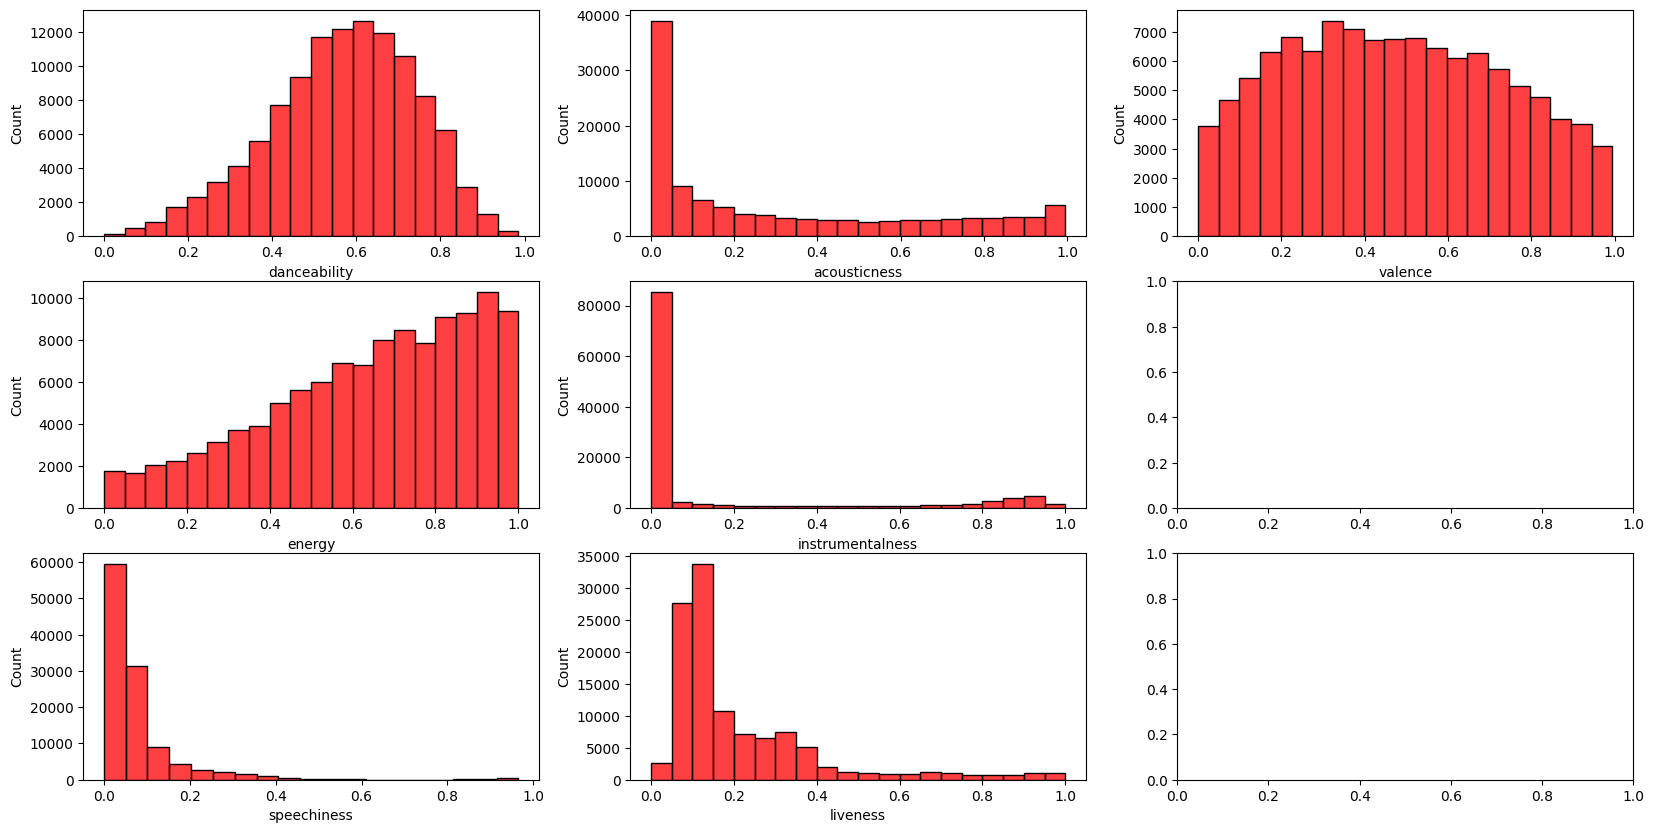

In [68]:
multiplotter(3, 3, (20, 10), non_unit_num, df_music)

<Axes: xlabel='popularity', ylabel='Count'>

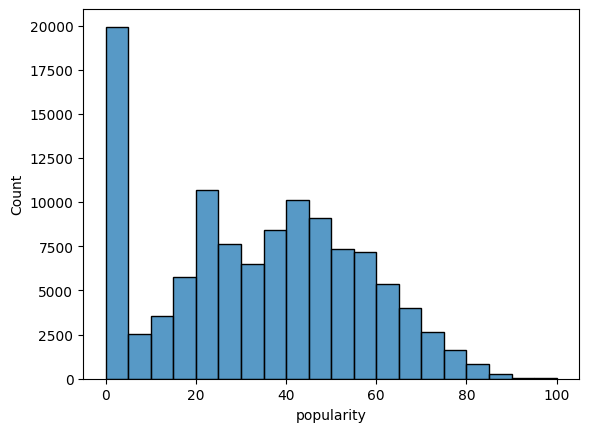

In [69]:
## Assessing Polpularity of SOngs in the Dataset
sns.histplot(df_music['popularity'], binwidth = 5)

In [70]:
## It is evident from the code above that a lot of songs in the dataset are not very popular

## Assessing Boolean Values in the Dataset
- explicit : Is the track has explicit lyrics? (True = Yes; False = No or Unknown)
- mode : What is the modality of the song? (0 = minor, 1 for major)

In [71]:
df_music['explicit'].value_counts() / len(df_music)

explicit
False    0.914416
True     0.085584
Name: count, dtype: float64

In [72]:
# The explicit values are too imbalanced, it would be deleted

<Axes: xlabel='mode', ylabel='valence'>

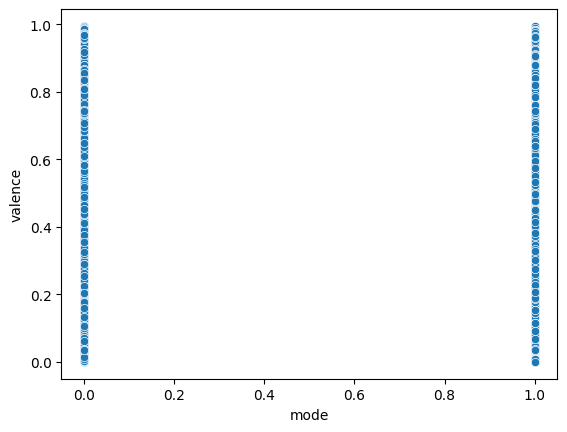

In [73]:
# Comparison between mode and valence
sns.scatterplot(df_music, x = 'mode', y = 'valence')

In [74]:
# From the above Plot there is no Correlation between mode and valence

In [75]:
# mode music distribution
df_music['mode'].value_counts() / len(df_music)

mode
1    0.637866
0    0.362134
Name: count, dtype: float64

In [76]:
deleted_column = ['time_signature', 'track_id', 'artists',
                 'album_name', 'track_name', 'popularity', 'explicit']
df_music_2 = df_music.drop(deleted_column, axis = 1).copy()

In [77]:
df_music_2.head(5)

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,230666,0.676,0.4610,1,0.459939,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,149610,0.420,0.1660,1,0.137483,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,210826,0.438,0.3590,0,0.326062,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,201933,0.266,0.0596,0,0.118645,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,198853,0.618,0.4430,2,0.328058,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [78]:
df_music_2.duplicated().sum()

30071

In [79]:
df_music_2.drop_duplicates(inplace = True)

In [80]:
# column subdivision
unit_num = ['duration_ms', 'loudness', 'tempo']
divide_01 = ['acousticness', 'instrumentalness', 'speechiness', 'liveness']
kept_it = ['danceability', 'valence', 'energy']
categ = ['key']
booleaning = ['mode']

## Outlier Handling

In [81]:
### Outlier Test
#Source: https://www.kaggle.com/code/nareshbhat/outlier-the-silent-killer

# Is there an outlier?
def check_outlier(x):
    g_cal = max(abs(x - x.mean())) / x.std()
    g_crit_1 = (len(x) - 1) / pow(len(x), 0.5)
    t_val = stats.t.ppf(1- 0.05 / (2 * len(x)), len(x) - 2)
    g_crit_2 = pow(t_val / (len(x) - 2 + pow(t_val, 2)), 0.5)
    return True if (g_cal > g_crit_1 * g_crit_2) else False
# find index that has outlier value
def drop_outlier(x):
    zed = abs(x - x.mean()) / x.std()
    return zed[zed > 3].index

# - Drop if there's a few and near outliers
# - Transform or Impute if there's a lot of outliers and it's out there


In [82]:
for i in unit_num:
    print(i, check_outlier(df_music_2[i]))

duration_ms True
loudness True
tempo True


In [83]:
# Outlier handling
index_outlier = []
for i in unit_num:
    index_outlier += list(drop_outlier(df_music_2[i]))
dropping_index = list(set(index_outlier))

In [84]:
len(dropping_index)

920

In [85]:
len(df_music_2)

83478

In [86]:
df_music_2.drop(dropping_index, inplace= True)

## Feature Engineering

0 0
1 0
0 1
1 1


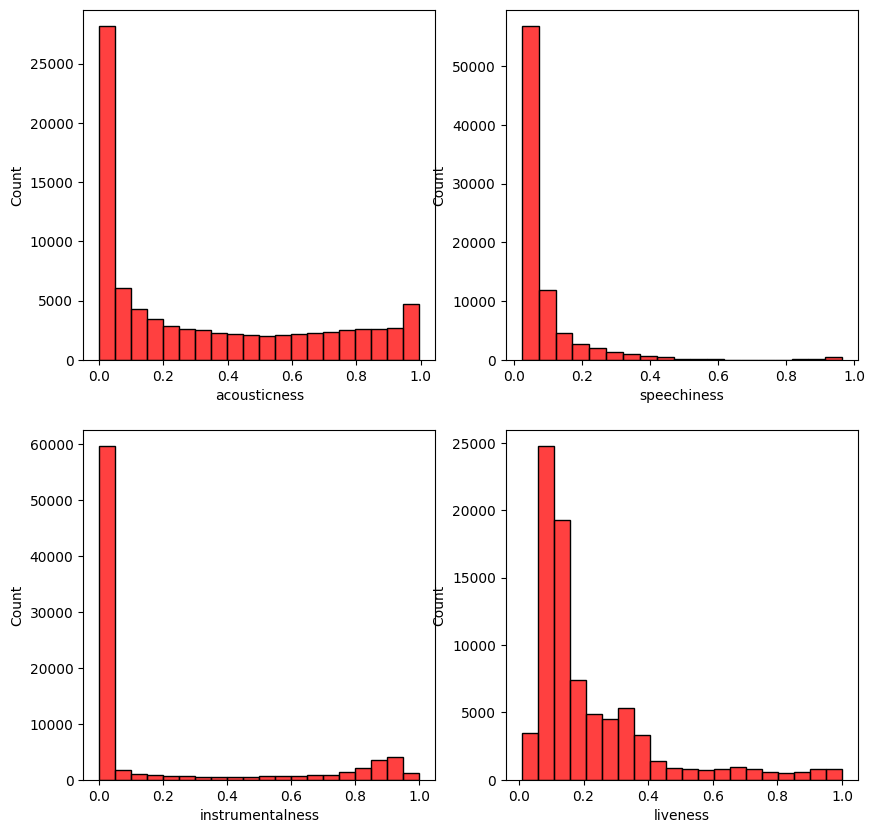

In [87]:
multiplotter(2, 2, (10, 10), divide_01, df_music_2)

# fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (20, 10)) #Numbers and size of plots

# # Initializing subplot position
# x = 0
# y = 0

# # Looping several subplots of distribution charts
# for i in divide_01:
#     sns.histplot(df_music_2[i], binwidth= 0.05, color = 'red', ax = ax[x,y])
#     print(x, y)
#     x += 1 # Move to the right
#     if x == 2: # Move below
#         x = 0
#         y += 1

In [88]:
#What is the percentage of imbalance between two parts of the column
for i in divide_01:
    print(i, len(df_music_2[df_music_2[i] > 0.5]) / len(df_music_2))

acousticness 0.31417912255626346
instrumentalness 0.190520603696795
speechiness 0.013166501126480778
liveness 0.08934324959422467


In [89]:
# I decided to drop speechiness and liveness due to imbalanced value

In [90]:
df_music_2.drop(['speechiness', 'liveness'], axis = 1, inplace = True)
df_music_2.drop_duplicates(inplace = True)

In [91]:
# Replace acousticness and instrumentalness to boolean value if the value is more than 0.5
df_music_2['acousticness_2'] = df_music_2['acousticness'] > 0.5
df_music_2['instrumentalness_2'] = df_music_2['instrumentalness'] > 0.5
df_music_2.drop(['acousticness', 'instrumentalness'], axis = 1, inplace = True)
df_music_2.head(5)

,duration_ms,danceability,energy,key,loudness,mode,valence,tempo,acousticness_2,instrumentalness_2
0,230666,0.676,0.4610,1,0.459939,0,0.715,87.917,False,False
1,149610,0.420,0.1660,1,0.137483,1,0.267,77.489,True,False
2,210826,0.438,0.3590,0,0.326062,1,0.120,76.332,False,False
3,201933,0.266,0.0596,0,0.118645,1,0.143,181.740,True,False
4,198853,0.618,0.4430,2,0.328058,1,0.167,119.949,False,False


In [92]:
# Dummifies the key
df_music_3 = df_music_2.join(pd.get_dummies(df_music_2['key'], prefix = 'key')).copy()
df_music_3.drop('key', axis = 1, inplace = True)

In [93]:
df_music_3.head(5)

,duration_ms,danceability,energy,loudness,mode,valence,tempo,acousticness_2,instrumentalness_2,key_0,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,230666,0.676,0.4610,0.459939,0,0.715,87.917,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,149610,0.420,0.1660,0.137483,1,0.267,77.489,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,210826,0.438,0.3590,0.326062,1,0.120,76.332,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,201933,0.266,0.0596,0.118645,1,0.143,181.740,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,198853,0.618,0.4430,0.328058,1,0.167,119.949,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [94]:
df_music_3.duplicated().sum()

19

## Scaling

In [95]:
# Scaling first
df_scaled = pd.DataFrame(StandardScaler().fit_transform(df_music_3), columns = df_music_3.columns)
df_scaled.head(5)

,duration_ms,danceability,energy,loudness,mode,valence,tempo,acousticness_2,instrumentalness_2,key_0,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,0.054291,0.653282,-0.685677,0.183401,-1.315950,0.943007,-1.164075,-0.676884,-0.48517,-0.359441,...,-0.343516,-0.176794,-0.297521,-0.296023,-0.269638,-0.367132,-0.254728,-0.335058,-0.264353,-0.293985
1,-0.928428,-0.811600,-1.834805,-1.628502,0.759907,-0.765046,-1.516100,1.477359,-0.48517,-0.359441,...,-0.343516,-0.176794,-0.297521,-0.296023,-0.269638,-0.367132,-0.254728,-0.335058,-0.264353,-0.293985
2,-0.186248,-0.708600,-1.083003,-0.568864,0.759907,-1.325501,-1.555157,-0.676884,-0.48517,2.782099,...,-0.343516,-0.176794,-0.297521,-0.296023,-0.269638,-0.367132,-0.254728,-0.335058,-0.264353,-0.293985
3,-0.294066,-1.692817,-2.249271,-1.734355,0.759907,-1.237811,2.003171,1.477359,-0.48517,2.782099,...,-0.343516,-0.176794,-0.297521,-0.296023,-0.269638,-0.367132,-0.254728,-0.335058,-0.264353,-0.293985
4,-0.331408,0.321394,-0.755794,-0.557650,0.759907,-1.146308,-0.082749,-0.676884,-0.48517,-0.359441,...,2.911073,-0.176794,-0.297521,-0.296023,-0.269638,-0.367132,-0.254728,-0.335058,-0.264353,-0.293985


## Feature Selection with Mutual Information

In [96]:
mut_inf = {}
for i in df_scaled.columns:
    mut_inf[i] = (mutual_info_regression(df_scaled.drop(i, axis = 1), df_scaled[i]))
mut_inf_df = pd.DataFrame(mut_inf)
avg_mi = (mut_inf_df.sum() / len(mut_inf_df)).sort_values(ascending = False)

In [97]:
avg_mi[avg_mi > avg_mi.sum() / len(avg_mi)]

energy                0.056731
loudness              0.050227
danceability          0.027897
tempo                 0.025712
acousticness_2        0.025424
valence               0.023386
duration_ms           0.015423
instrumentalness_2    0.014357
dtype: float64

In [98]:
df_fs = df_scaled[avg_mi[avg_mi > avg_mi.sum() / len(avg_mi)].index].copy()

In [99]:
df_fs.head(5)

,energy,loudness,danceability,tempo,acousticness_2,valence,duration_ms,instrumentalness_2
0,-0.685677,0.183401,0.653282,-1.164075,-0.676884,0.943007,0.054291,-0.48517
1,-1.834805,-1.628502,-0.811600,-1.516100,1.477359,-0.765046,-0.928428,-0.48517
2,-1.083003,-0.568864,-0.708600,-1.555157,-0.676884,-1.325501,-0.186248,-0.48517
3,-2.249271,-1.734355,-1.692817,2.003171,1.477359,-1.237811,-0.294066,-0.48517
4,-0.755794,-0.557650,0.321394,-0.082749,-0.676884,-1.146308,-0.331408,-0.48517


In [100]:
# The main PCA function
def pca_main(df, comp):
    pca = PCA(n_components = comp)
    results = pca.fit_transform(df)
    var_rat = pca.explained_variance_ratio_
    return var_rat, results

# Repeated PCA function until explained variance ratio sum near 90%
def pca_feature(df):
    var_rat, results = pca_main(df, len(df.columns))
    summa = 0
    for i in range(0, len(var_rat)):
        summa += var_rat[i]
        if summa >= 0.9:
            break
    print(i, 'features')
    var_rat, results = pca_main(df, i)
    return results

In [101]:
result_pca = pca_feature(df_fs)
df_pca = pd.DataFrame(result_pca, columns = ['PC_' + str(i) for i in range(len(result_pca[0]))])

5 features


In [102]:
for i in range(2, 6):
    km = KMeans(n_clusters=i, random_state=99, n_init="auto").fit_predict(df_pca)
    print(i, ":", silhouette_score(df_pca, km))

2 : 0.290218177014964
3 : 0.21403849051575244
4 : 0.21967980121835687
5 : 0.2322530949435343


In [103]:
km = KMeans(n_clusters=2, random_state=99, init="k-means++", n_init = 'auto').fit_predict(df_pca)
print(2, ":", silhouette_score(df_pca, km))

2 : 0.290218177014964


In [104]:
df_music_4 = df_music_3.copy()
df_music_4['cluster'] = km

In [105]:
df_music_4

,duration_ms,danceability,energy,loudness,mode,valence,tempo,acousticness_2,instrumentalness_2,key_0,...,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,cluster
0,230666,0.676,0.4610,0.459939,0,0.7150,87.917,False,False,False,...,False,False,False,False,False,False,False,False,False,0
1,149610,0.420,0.1660,0.137483,1,0.2670,77.489,True,False,False,...,False,False,False,False,False,False,False,False,False,1
2,210826,0.438,0.3590,0.326062,1,0.1200,76.332,False,False,True,...,False,False,False,False,False,False,False,False,False,1
3,201933,0.266,0.0596,0.118645,1,0.1430,181.740,True,False,True,...,False,False,False,False,False,False,False,False,False,1
4,198853,0.618,0.4430,0.328058,1,0.1670,119.949,False,False,False,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,384999,0.172,0.2350,0.151478,1,0.0339,125.995,True,True,False,...,False,False,True,False,False,False,False,False,False,1
113996,385000,0.174,0.1170,0.121367,0,0.0350,85.239,True,True,True,...,False,False,False,False,False,False,False,False,False,1
113997,271466,0.629,0.3290,0.285266,0,0.7430,132.378,True,False,True,...,False,False,False,False,False,False,False,False,False,1
113998,283893,0.587,0.5060,0.285463,1,0.4130,135.960,False,False,False,...,False,False,False,False,True,False,False,False,False,0


In [106]:
df_music_4['cluster'].value_counts()

cluster
0    57205
1    25345
Name: count, dtype: int64

In [107]:
df_music_4[df_music_4['cluster'] == 0].describe()

,duration_ms,danceability,energy,loudness,mode,valence,tempo,cluster
count,57205.000000,57205.000000,57205.000000,57205.000000,57205.000000,57205.000000,57205.000000,57205.0
mean,233252.413740,0.592187,0.766989,0.505737,0.611433,0.517616,127.239241,0.0
std,80329.992029,0.163282,0.157172,0.137467,0.487429,0.256347,28.232214,0.0
min,24266.000000,0.051300,0.180000,0.075858,0.000000,0.000010,36.950000,0.0
25%,182493.000000,0.487000,0.654000,0.410251,0.000000,0.311000,105.004000,0.0
50%,220000.000000,0.603000,0.788000,0.504313,1.000000,0.521000,125.939000,0.0
75%,269533.000000,0.714000,0.902000,0.597585,1.000000,0.727000,145.075000,0.0
max,577680.000000,0.985000,1.000000,0.965162,1.000000,0.995000,211.945000,0.0


In [108]:
df_music_4[df_music_4['cluster'] == 1].describe()

,duration_ms,danceability,energy,loudness,mode,valence,tempo,cluster
count,25345.000000,25345.000000,25345.000000,25345.000000,25345.000000,25345.000000,25345.000000,25345.0
mean,210243.175616,0.493324,0.343689,0.250263,0.684711,0.354912,111.478437,1.0
std,85013.937805,0.180350,0.186354,0.123601,0.464640,0.239599,29.783278,0.0
min,15800.000000,0.054500,0.000020,0.004682,0.000000,0.000000,34.262000,1.0
25%,153530.000000,0.371000,0.208000,0.156783,0.000000,0.159000,87.018000,1.0
50%,198626.000000,0.506000,0.342000,0.250006,1.000000,0.315000,109.936000,1.0
75%,254267.000000,0.625000,0.466000,0.339391,1.000000,0.517000,130.768000,1.0
max,577293.000000,0.980000,1.000000,0.764892,1.000000,0.988000,212.246000,1.0


In [109]:
df_music_4['key'] = pd.from_dummies(df_music_4[['key_' + str(i) for i in range(0, 12)]])
df_music_4.drop(['key_' + str(i) for i in range(0, 12)], axis = 1, inplace = True)

In [110]:
df_music_4.head(5)

,duration_ms,danceability,energy,loudness,mode,valence,tempo,acousticness_2,instrumentalness_2,cluster,key
0,230666,0.676,0.4610,0.459939,0,0.715,87.917,False,False,0,key_1
1,149610,0.420,0.1660,0.137483,1,0.267,77.489,True,False,1,key_1
2,210826,0.438,0.3590,0.326062,1,0.120,76.332,False,False,1,key_0
3,201933,0.266,0.0596,0.118645,1,0.143,181.740,True,False,1,key_0
4,198853,0.618,0.4430,0.328058,1,0.167,119.949,False,False,0,key_2


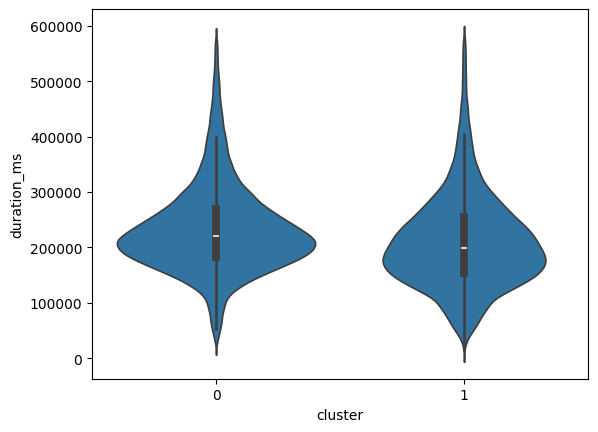

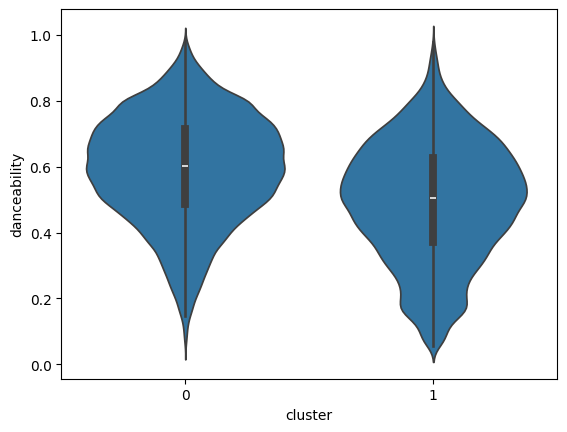

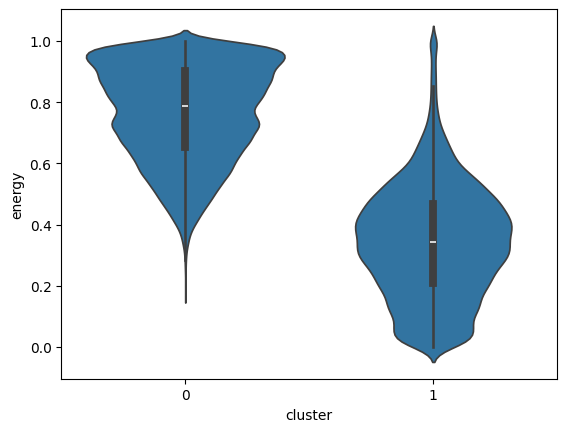

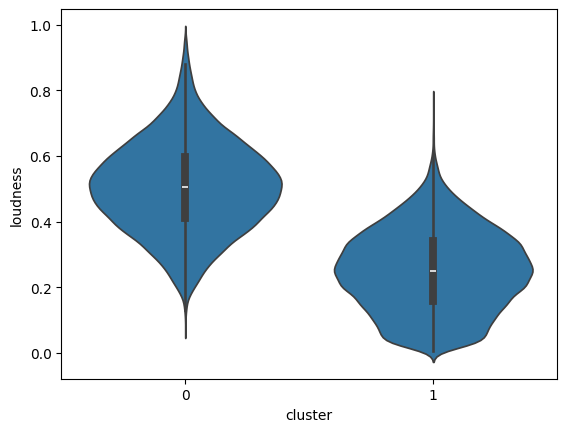

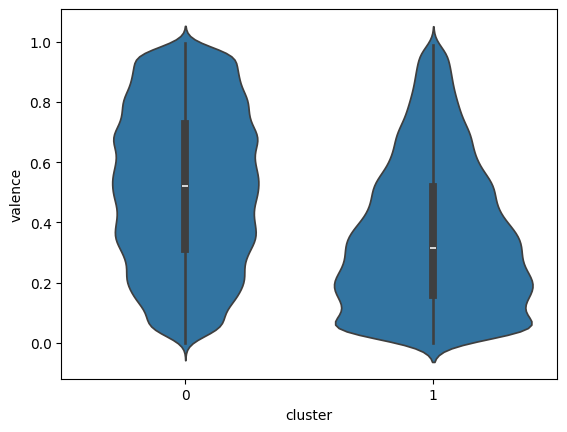

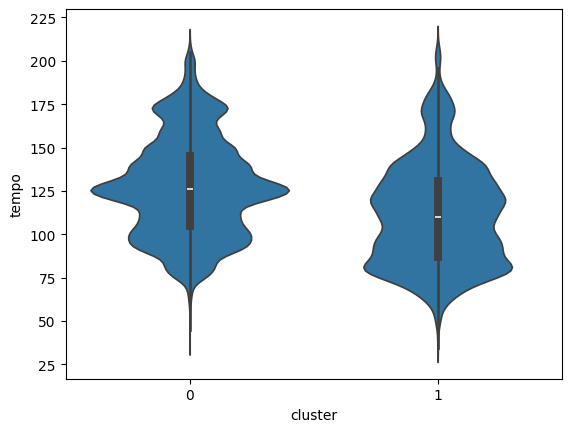

In [111]:
for i in ['duration_ms', 'danceability', 'energy', 'loudness', 'valence', 'tempo']:
    sns.violinplot(df_music_4, x = 'cluster', y = i)
    plt.show()

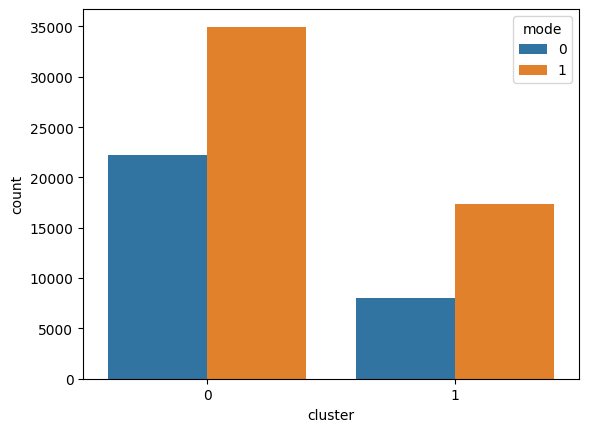

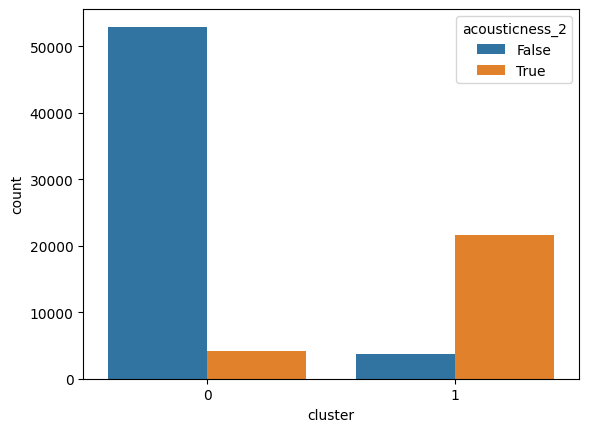

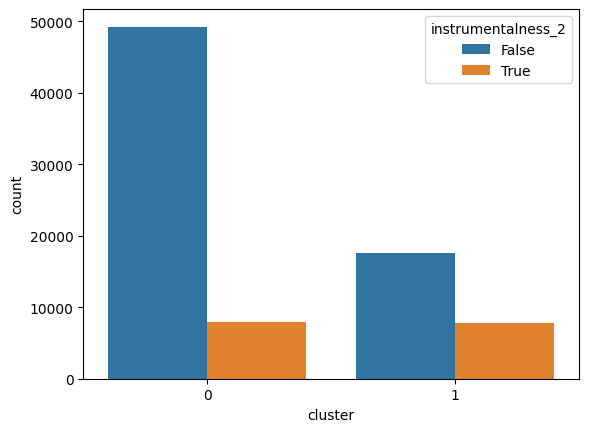

In [112]:
for i in ['mode', 'acousticness_2', 'instrumentalness_2']:
    sns.countplot(df_music_4, x = 'cluster', hue = i)
    plt.show()

<Axes: xlabel='key', ylabel='count'>

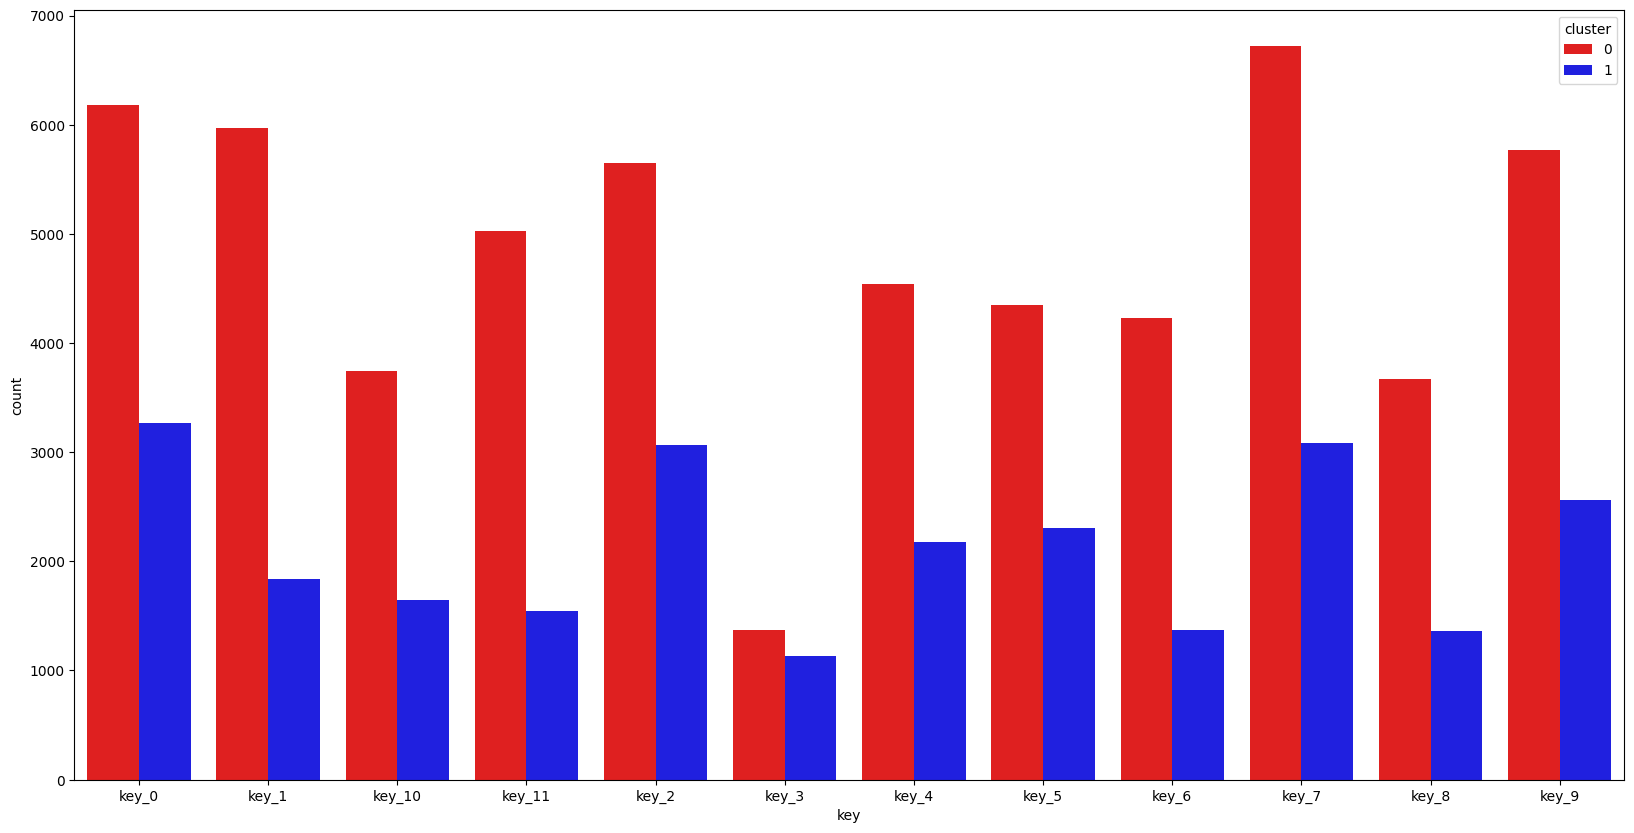

In [113]:
plt.figure(figsize = (20, 10))
sns.countplot(df_music_4.sort_values('key'), x = 'key', hue = 'cluster', palette = {0 :'red', 1:'blue'})

In [114]:
df_music_4[df_music_4['cluster'] == 0]['key'].value_counts().sort_index() / len(df_music_4[df_music_4['cluster'] == 0])

key
key_0     0.108067
key_1     0.104327
key_10    0.065449
key_11    0.087790
key_2     0.098680
key_3     0.023949
key_4     0.079311
key_5     0.076025
key_6     0.073892
key_7     0.117455
key_8     0.064208
key_9     0.100848
Name: count, dtype: float64

In [115]:
df_music_4[df_music_4['cluster'] == 1]['key'].value_counts().sort_index() / len(df_music_4[df_music_4['cluster'] == 1])

key
key_0     0.128743
key_1     0.072480
key_10    0.065023
key_11    0.060959
key_2     0.121050
key_3     0.044664
key_4     0.085855
key_5     0.090827
key_6     0.053975
key_7     0.121760
key_8     0.053541
key_9     0.101124
Name: count, dtype: float64

# K- Means Cluster Analysis

K-Means Cluster Analysis: Exploring Genre Boundaries
The analysis revealed two distinct clusters of music based on audio features:

Cluster 0 (Soft/Acoustic Music)

Characteristics: Lower energy, loudness, and valence; higher acousticness/instrumentalness.

Genre Alignment: Likely aligns with traditional genres like folk, acoustic, or ambient due to its subdued, non-vocal-heavy nature.

Notable Insight: The concentration of low valence suggests these tracks may represent subgenres like sadcore or dark folk, which are traditionally slower and more melancholic.

Cluster 1 (Hard/Energetic Music)

Characteristics: High energy, loudness, and variable valence; low acousticness/instrumentalness.

Genre Alignment: Matches conventional rock, electronic, or hip-hop genres, but the wide valence range implies hybridity (e.g., emo rap blending aggression and sadness).

Notable Insight: The spread of valence values challenges strict genre boundaries, suggesting this cluster may include genre-blurring tracks (e.g., energetic but sad songs).

Objective Fulfillment

Genre Boundaries: Clusters loosely align with traditional genres but highlight feature overlaps (e.g., both clusters share tempo/danceability ranges, defying genre stereotypes).

Hybrid Genres: Cluster 1’s valence diversity suggests it captures genre hybrids (e.g., upbeat songs with sad lyrics).

Outliers: Tracks with mismatched features (e.g., high energy + high acousticness) could represent experimental genres or data noise.

Recommendations for Further Analysis

Cross-reference clusters with the track_genre column to validate genre alignment.

Use DBSCAN to detect outliers (potential genre innovators).

## Feature Selection with Mutual Information

K-Means Cluster Analysis: Exploring Genre Boundaries
The analysis revealed two distinct clusters of music based on audio features:

Cluster 0 (Soft/Acoustic Music)

Characteristics: Lower energy, loudness, and valence; higher acousticness/instrumentalness.

Genre Alignment: Likely aligns with traditional genres like folk, acoustic, or ambient due to its subdued, non-vocal-heavy nature.

Notable Insight: The concentration of low valence suggests these tracks may represent subgenres like sadcore or dark folk, which are traditionally slower and more melancholic.

Cluster 1 (Hard/Energetic Music)

Characteristics: High energy, loudness, and variable valence; low acousticness/instrumentalness.

Genre Alignment: Matches conventional rock, electronic, or hip-hop genres, but the wide valence range implies hybridity (e.g., emo rap blending aggression and sadness).

Notable Insight: The spread of valence values challenges strict genre boundaries, suggesting this cluster may include genre-blurring tracks (e.g., energetic but sad songs).

Objective Fulfillment

Genre Boundaries: Clusters loosely align with traditional genres but highlight feature overlaps (e.g., both clusters share tempo/danceability ranges, defying genre stereotypes).

Hybrid Genres: Cluster 1’s valence diversity suggests it captures genre hybrids (e.g., upbeat songs with sad lyrics).

Outliers: Tracks with mismatched features (e.g., high energy + high acousticness) could represent experimental genres or data noise.

Recommendations for Further Analysis

Cross-reference clusters with the track_genre column to validate genre alignment.

Use DBSCAN to detect outliers (potential genre innovators).